# Benchmark Raw GEx
Benchmark using as baseline raw GEx

# 0. Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-13-21") # A 
run_dir = os.path.join("..","..","outputs","run-25-09-16-02") 
output_dir = os.path.join(run_dir, "outputs")


if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

    

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: 
library: RNA-Seq
use_controls: True
use_control_loss: False


In [4]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  


## 0.2 Load DO Pairs

In [5]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


# 1. Compute Similarity Matrixes

In [6]:
"""Compute similarity matrixes
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable
split_idx = 0

# functions


# 2. Load Data
# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  


X_train = adata_train.X
X_train = np.where(np.isnan(X_train), 0, X_train)
X_valid = adata_valid.X
X_valid = np.where(np.isnan(X_valid), 0, X_valid)
X_test = adata_test.X
X_test = np.where(np.isnan(X_test), 0, X_test)


# compute correlation similarity between all embeddings
c_matrix_train =1 -  cdist(X_train, X_train, "correlation")
c_matrix_valid =1 -  cdist(X_valid, X_valid, "correlation")
c_matrix_test =1 -  cdist(X_test, X_test, "correlation")

# compute correlation similarity between sets
c_matrix_test_vs_train =1 -  cdist(X_test, X_train, "correlation")
c_matrix_valid_vs_train =1 - cdist(X_valid, X_train, "correlation")

# # save
# c_matrix_test_vs_train.astype(np.float16).tofile(os.path.join(output_dir, "c_matrix_test_vs_train.bin"))
# c_matrix_valid_vs_train.astype(np.float16).tofile(os.path.join(output_dir, "c_matrix_valid_vs_train.bin"))
# c_matrix_train.astype(np.float16).tofile(os.path.join(output_dir, "c_matrix_train.bin"))
# c_matrix_valid.astype(np.float16).tofile(os.path.join(output_dir, "c_matrix_valid.bin"))
# c_matrix_test.astype(np.float16).tofile(os.path.join(output_dir, "c_matrix_test.bin"))


In [7]:
# # load from saved numpy bin
# c_matrix_test_vs_train = np.fromfile(os.path.join(output_dir, "c_matrix_test_vs_train.bin"), dtype=np.float16)
# c_matrix_valid_vs_train = np.fromfile(os.path.join(output_dir, "c_matrix_valid_vs_train.bin"), dtype=np.float16)
# c_matrix_train = np.fromfile(os.path.join(output_dir, "c_matrix_train.bin"), dtype=np.float16)
# c_matrix_valid = np.fromfile(os.path.join(output_dir, "c_matrix_valid.bin"), dtype=np.float16)
# c_matrix_test = np.fromfile(os.path.join(output_dir, "c_matrix_test.bin"), dtype=np.float16)

# c_matrix_test_vs_train = c_matrix_test_vs_train.reshape(adata_test.n_obs, adata_train.n_obs)
# c_matrix_valid_vs_train = c_matrix_valid_vs_train.reshape(adata_valid.n_obs, adata_train.n_obs)
# c_matrix_train = c_matrix_train.reshape(adata_train.n_obs, adata_train.n_obs)
# c_matrix_valid = c_matrix_valid.reshape(adata_valid.n_obs, adata_valid.n_obs)
# c_matrix_test = c_matrix_test.reshape(adata_test.n_obs, adata_test.n_obs)

# 2. Benchmark Disease vs Control Similarity

In [ ]:
import importlib
importlib.reload(vz)

df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))


In [ ]:
"""2. Benchmark Disease vs Control Similarity

Structure:
    1. Imports, Variables, Functions
    2. Get Similarity
    3. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
from tqdm import tqdm
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# variables


# functions
# 2. Get Similarity
# define sets of related & unrelated 
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# train set
# same disease pairs
(tr_s_same_same,tr_s_same_diff,tr_s_ctrl_same, tr_s_ctrl_diff), (tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff) = vz.get_same_disease_sim(adata_train.obs, c_matrix_train)

# get unrelated pairs
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)

# validation set
(vl_s_same_diff, vl_s_ctrl_diff), ( vl_w_same_diff, vl_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_valid, adata_train, c_matrix_valid_vs_train,dsaid_2_dis)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)



# test set
(ts_s_same_diff, ts_s_ctrl_diff), ( ts_w_same_diff, ts_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_test, adata_train, c_matrix_test_vs_train,dsaid_2_dis)
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)




Processing same disease pairs:   0%|          | 0/277 [00:00<?, ?it/s]

Processing same disease pairs: 100%|██████████| 277/277 [01:16<00:00,  3.64it/s] 


277 diseases in dataset


38226it [03:12, 199.06it/s]


1778036527 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


 64%|██████▍   | 21836/34057 [14:37<15:42, 12.96it/s]  Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7a460da13890>>
Traceback (most recent call last):
  File "/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
 65%|██████▌   | 22142/34057 [14:56<08:02, 24.71it/s]

KeyboardInterrupt



In [ ]:
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)


100%|██████████| 34057/34057 [27:00<00:00, 21.01it/s]  


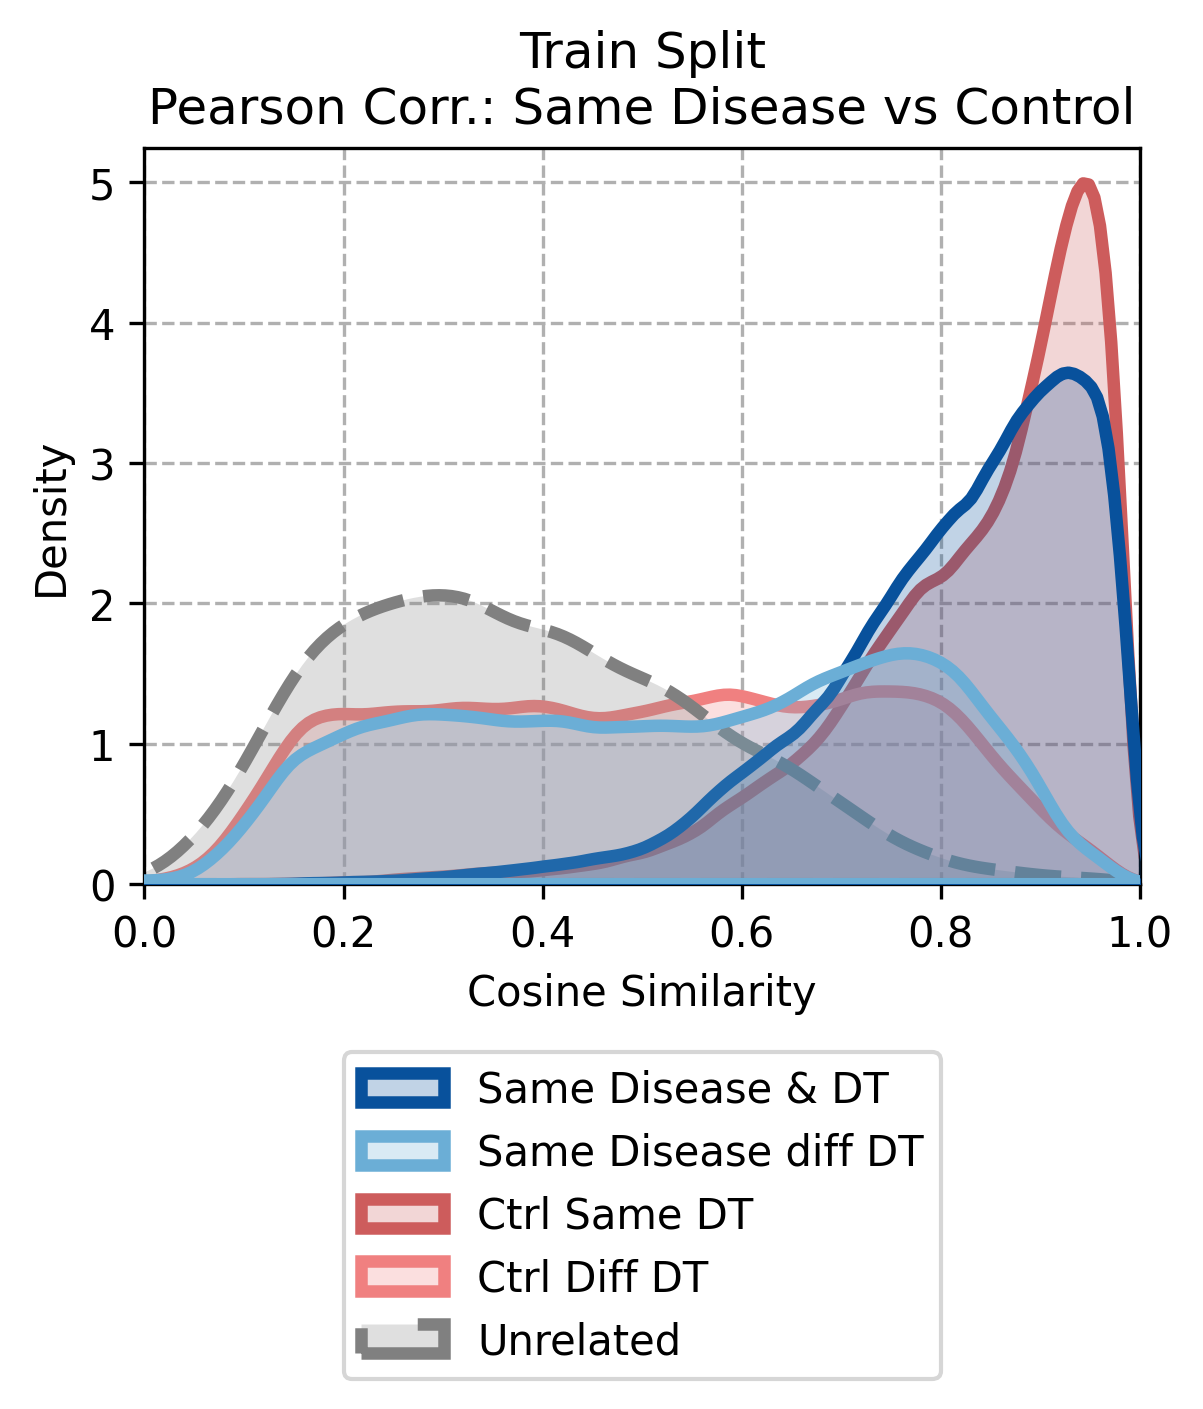

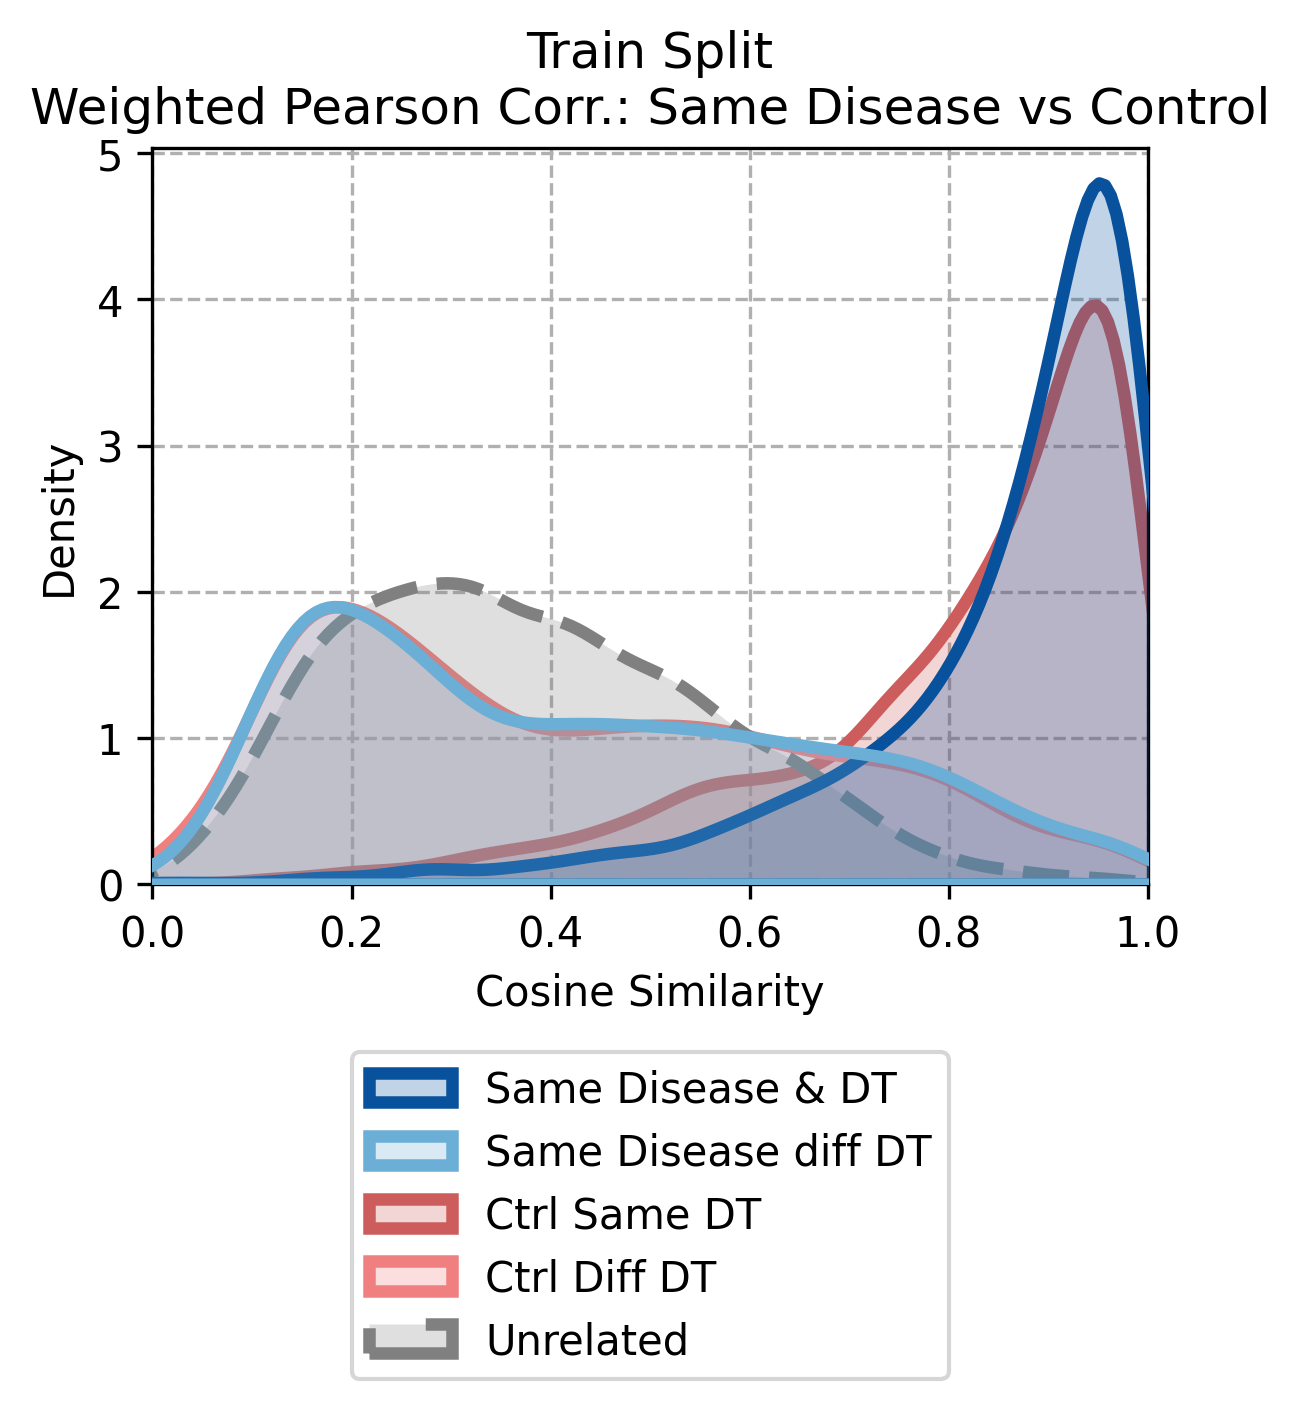

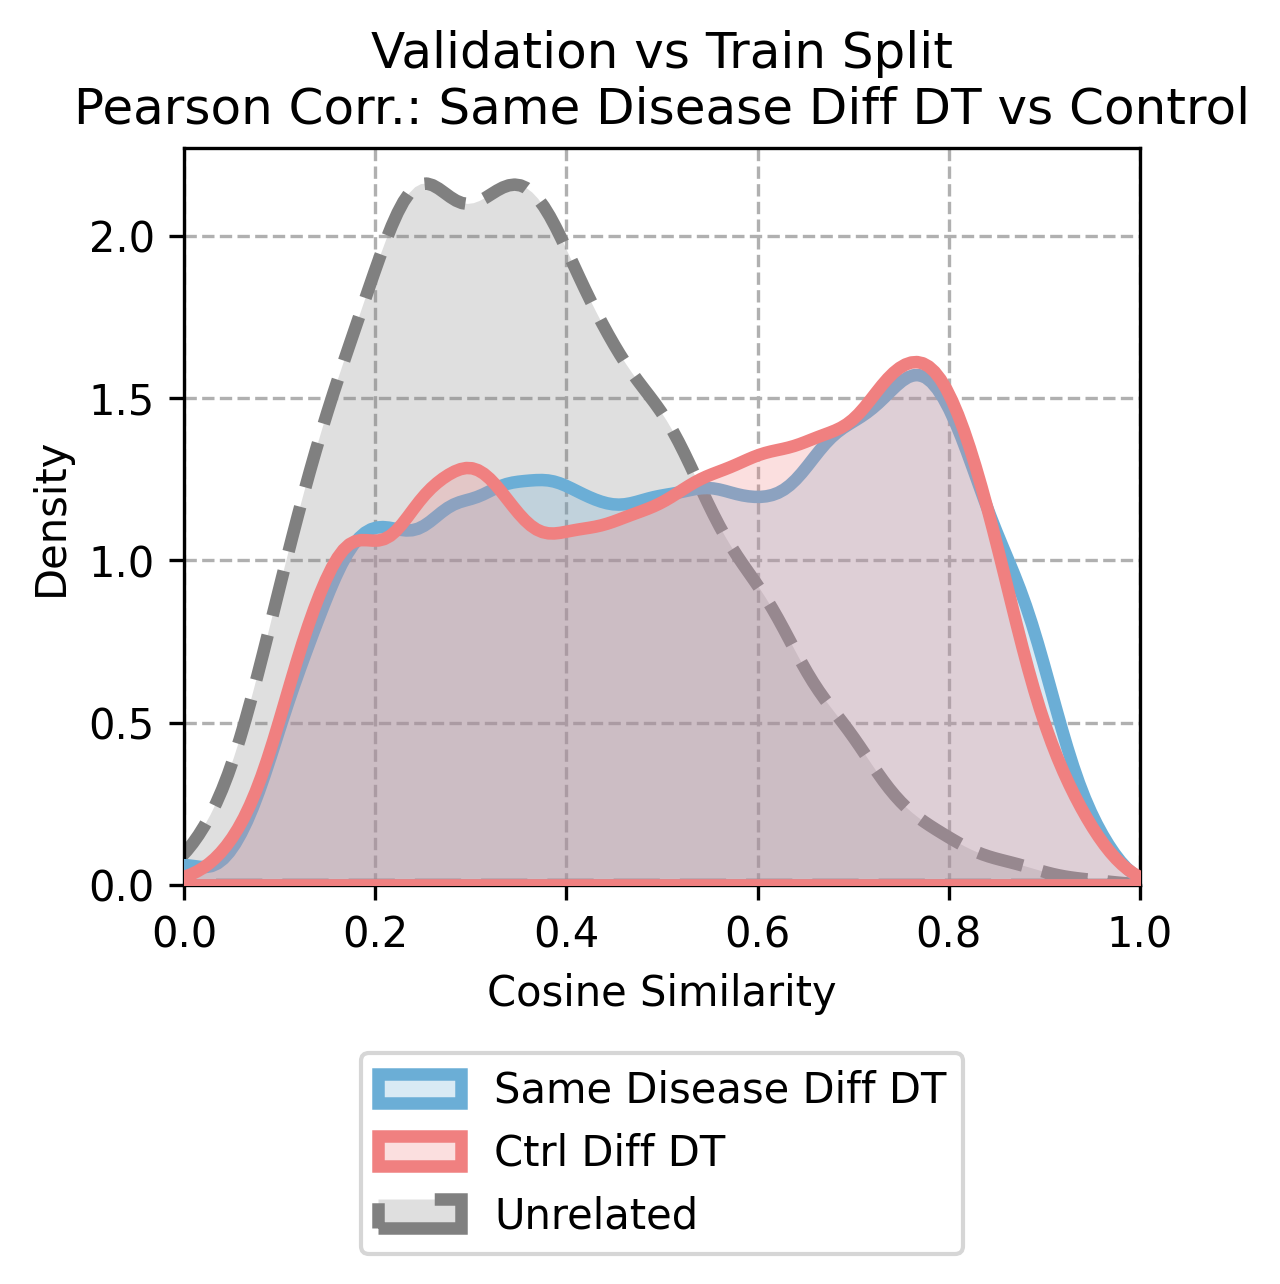

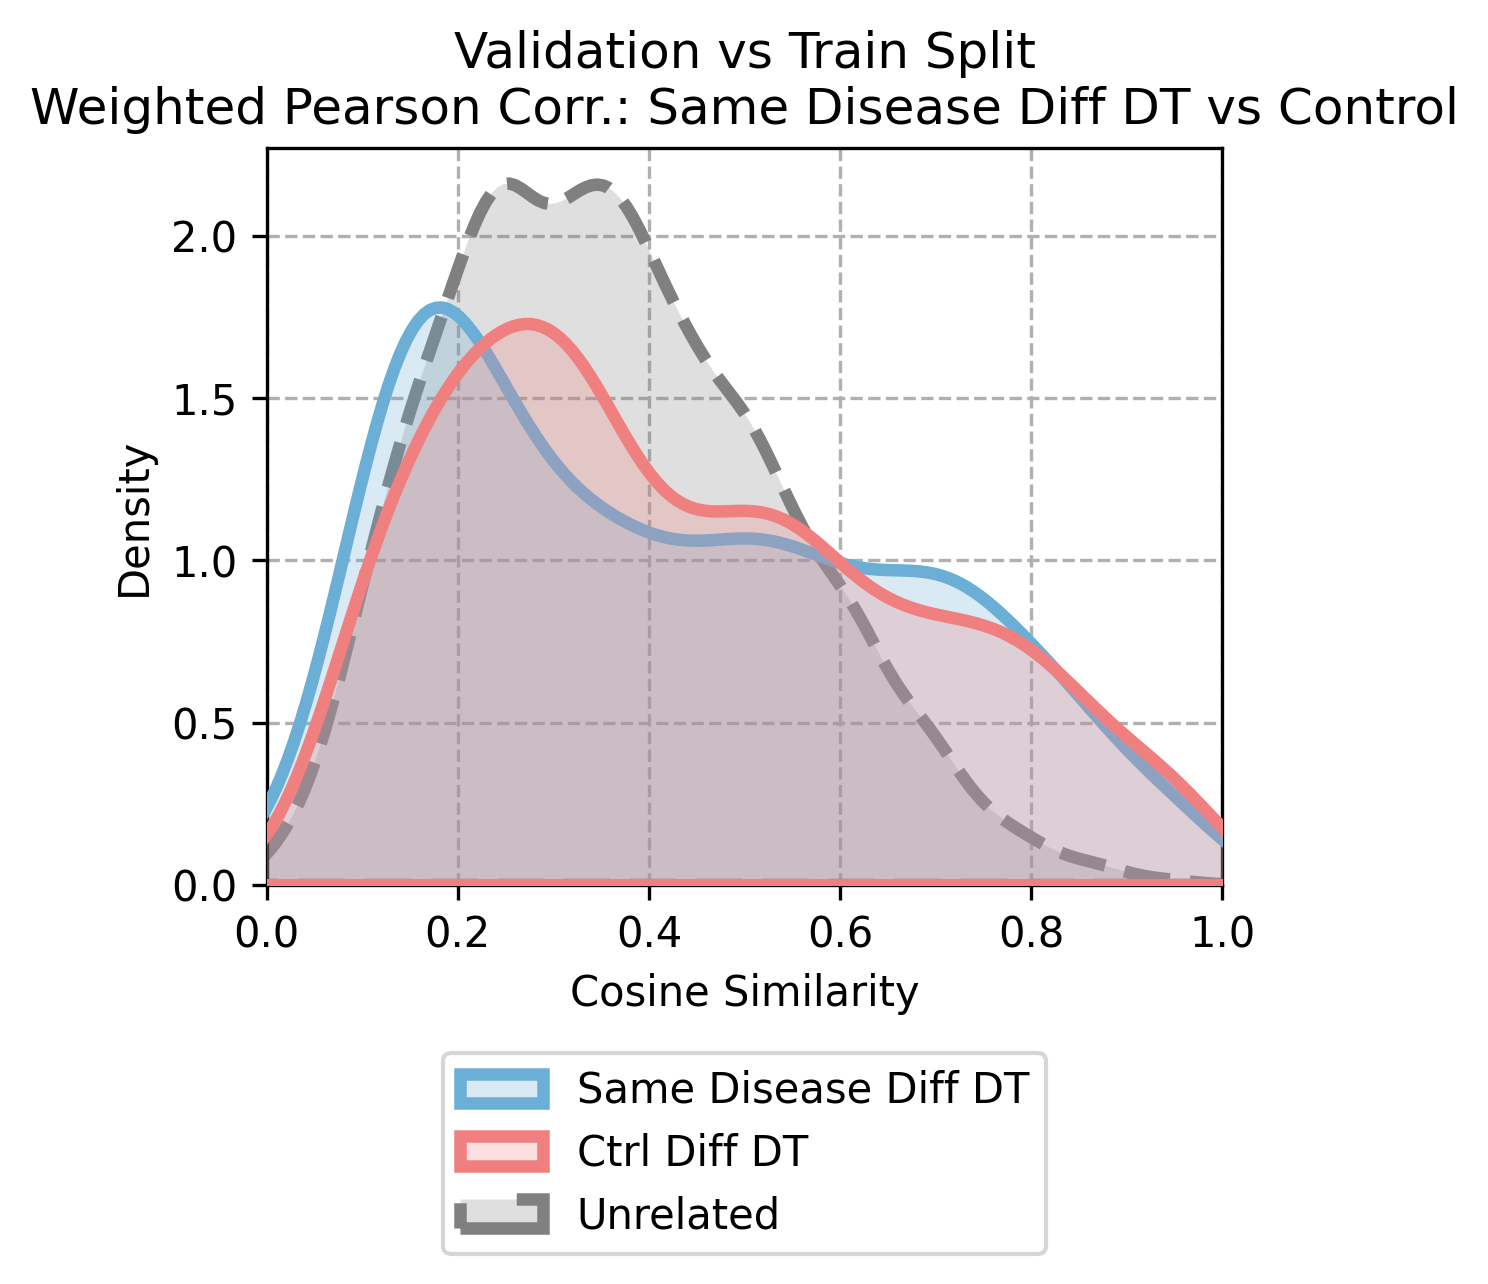

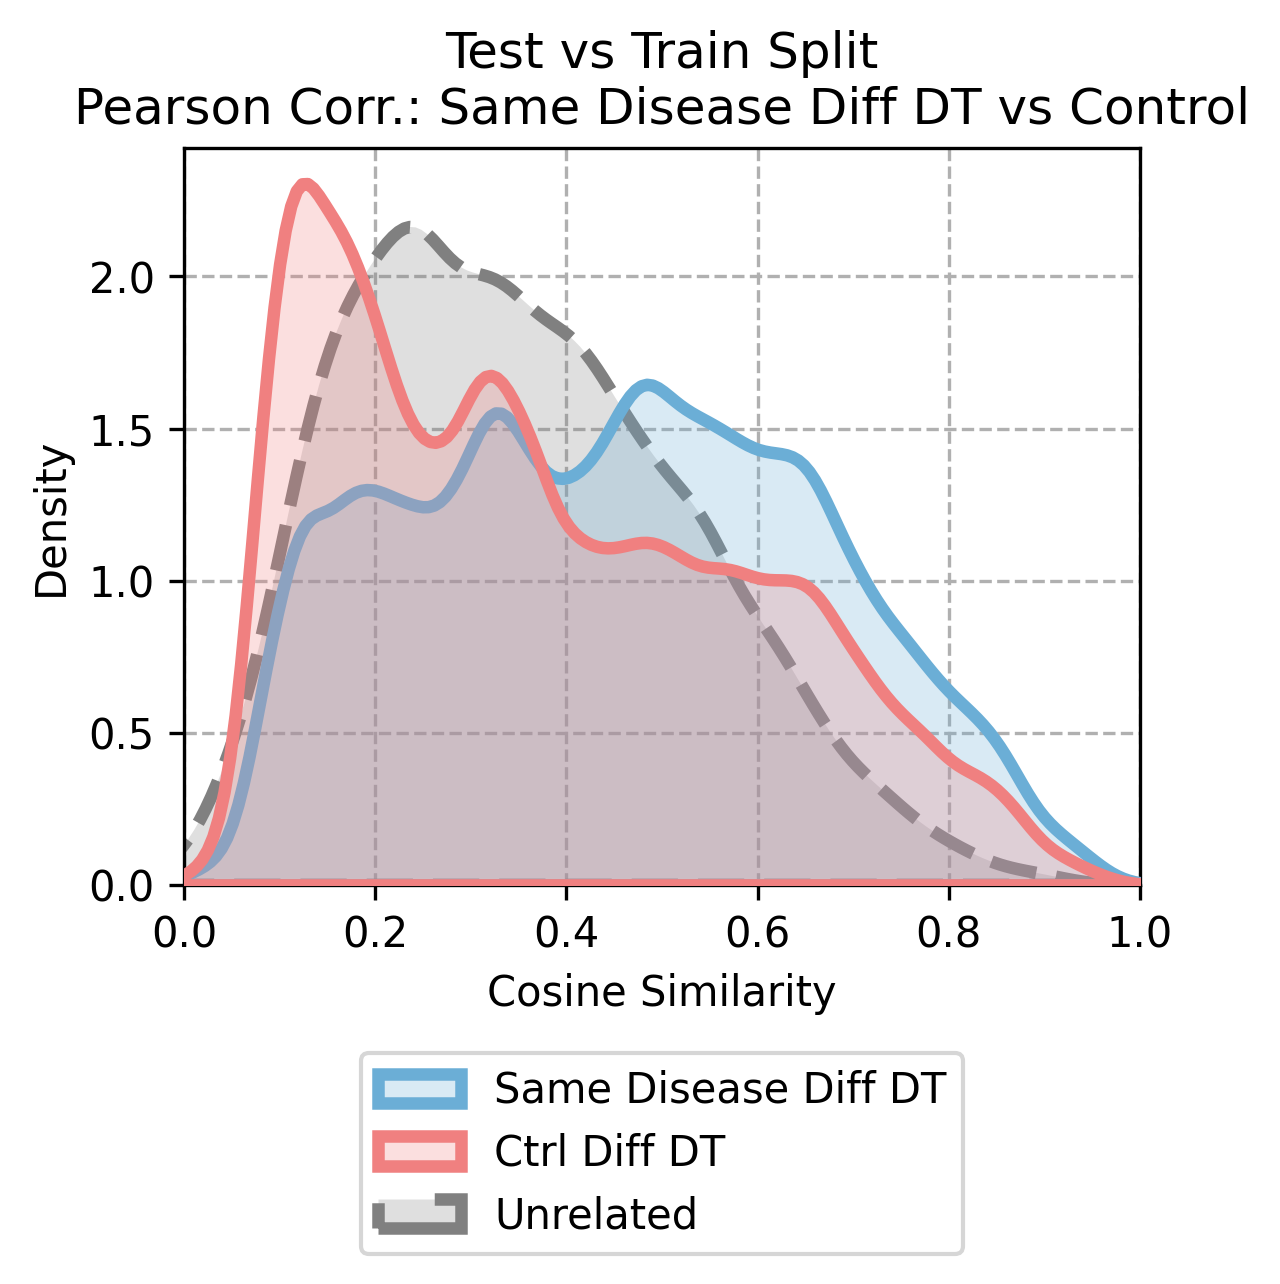

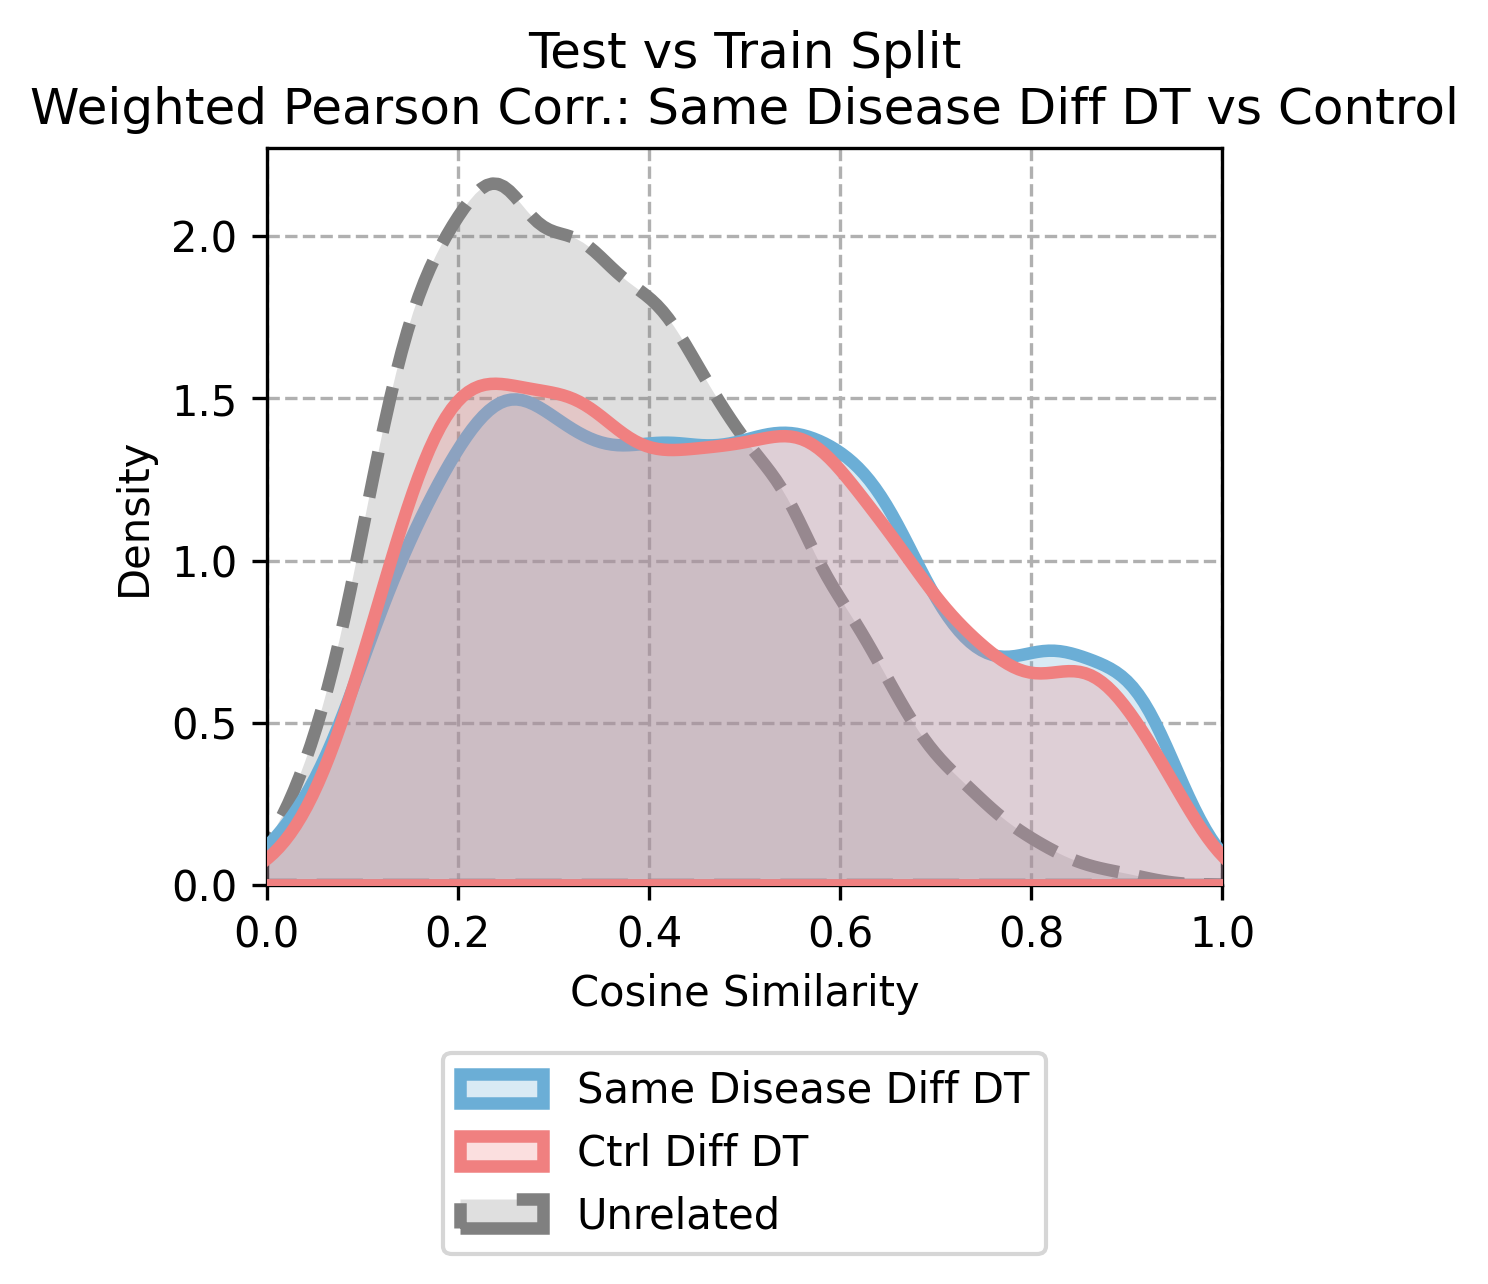

In [ ]:
# 3. Plot Similarity
dpi_val = 300
# train
# unweighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nPearson Corr.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_train_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nWeighted Pearson Corr.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff, None],output_dir=os.path.join(output_dir, "gex_kde_train_dis_id_w.png"),dpi=dpi_val, x_lim_val=(0,1))




# validation set
# unweighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nPearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_val_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nWeighted Pearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[vl_w_same_diff, vl_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_val_dis_id_w.png"), x_lim_val=(0,1))


# test set
# unweighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nPearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_test_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nWeighted Pearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[ts_w_same_diff, ts_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_dis_id_w.png"), x_lim_val=(0,1))


# 3. Benchmark Disease Related Disease Similarity

## 3.1 Plot KDE & AUROC

In [ ]:
"""Benchmark Disease Related Disease Similarity

Structure:
    1. Imports, Variables, Functions
    2. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
import random

# variables
sample_size = 10000

# functions
def get_bins(vals, bins):

    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list


# 2. Plot Similarity

# Type 1: Plot similarity based on semantic similarity
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# bin data based on similarity
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.8-1'","'0.6-0.8'","'0.4-0.6'"]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins


#! QUICK FIX ! SOME NAN VALUES 
c_matrix_test_ = np.where(np.isnan(c_matrix_test), 0, c_matrix_test)
c_matrix_train_ = np.where(np.isnan(c_matrix_train), 0, c_matrix_train)
c_matrix_valid_ = np.where(np.isnan(c_matrix_valid), 0, c_matrix_valid)
c_matrix_test_vs_train_ = np.where(np.isnan(c_matrix_test_vs_train), 0, c_matrix_test_vs_train)
c_matrix_valid_vs_train_ = np.where(np.isnan(c_matrix_valid_vs_train), 0, c_matrix_valid_vs_train)


# train
tr_s_all_1, tr_w_all_1, tr_l_all_1 = vz.get_related_dis_sim(
    adata_train, c_matrix_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size,
)

# valid
vl_s_all_1, vl_w_all_1, vl_l_all_1 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)

# test
ts_s_all_1, ts_w_all_1, ts_l_all_1 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)



100%|██████████| 34057/34057 [00:40<00:00, 835.61it/s] 


Nº of unrelated disease pairs: 779469229
[SP '0.8-1'] Nº of related disease pairs: 169


100%|██████████| 169/169 [00:13<00:00, 12.42it/s]


Nº of related disease pairs for '0.8-1': 6301503
[SP '0.6-0.8'] Nº of related disease pairs: 647


100%|██████████| 647/647 [01:20<00:00,  8.06it/s]


...

Nº of related disease pairs for '0.6-0.8': 12360350
[SP '0.4-0.6'] Nº of related disease pairs: 2922


100%|██████████| 2922/2922 [01:49<00:00, 26.73it/s] 


Nº of related disease pairs for '0.4-0.6': 48699217
Nº of diseases: 275


100%|██████████| 275/275 [00:06<00:00, 41.83it/s]


Nº of unrelated disease pairs: 48699217


In [ ]:



# Type 2: Plot similarity based on DO graph distance
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

labels = [2, 3, 5]  # define labels


# train
tr_s_all_2, tr_w_all_2, tr_l_all_2 = vz.get_related_dis_sim(
    adata_train, c_matrix_train_, df_related, df_unrelated, labels, sample=sample_size,
)

# valid
vl_s_all_2, vl_w_all_2, vl_l_all_2 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train_, df_related, df_unrelated, labels, sample=sample_size)

# test
ts_s_all_2, ts_w_all_2, ts_l_all_2 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train_, df_related, df_unrelated, labels, sample=sample_size)


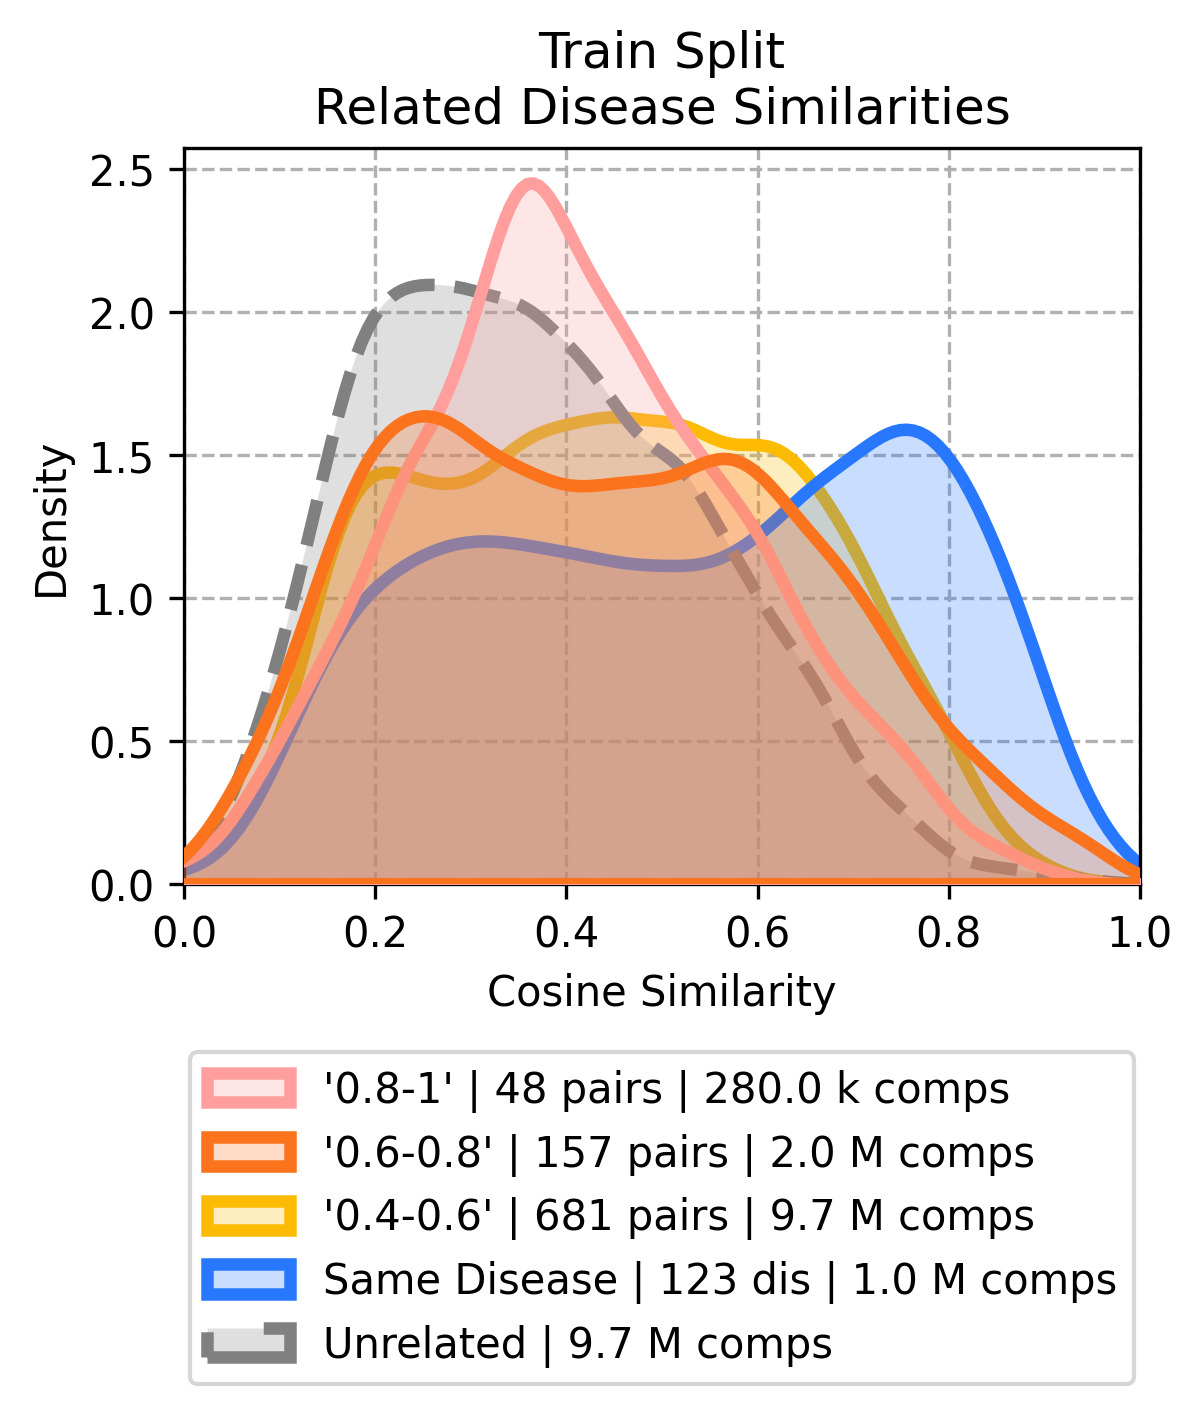

Nº of positive disease pairs: 279956
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1994824
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 9716963
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1043867
Nº of positive disease pairs: 10000


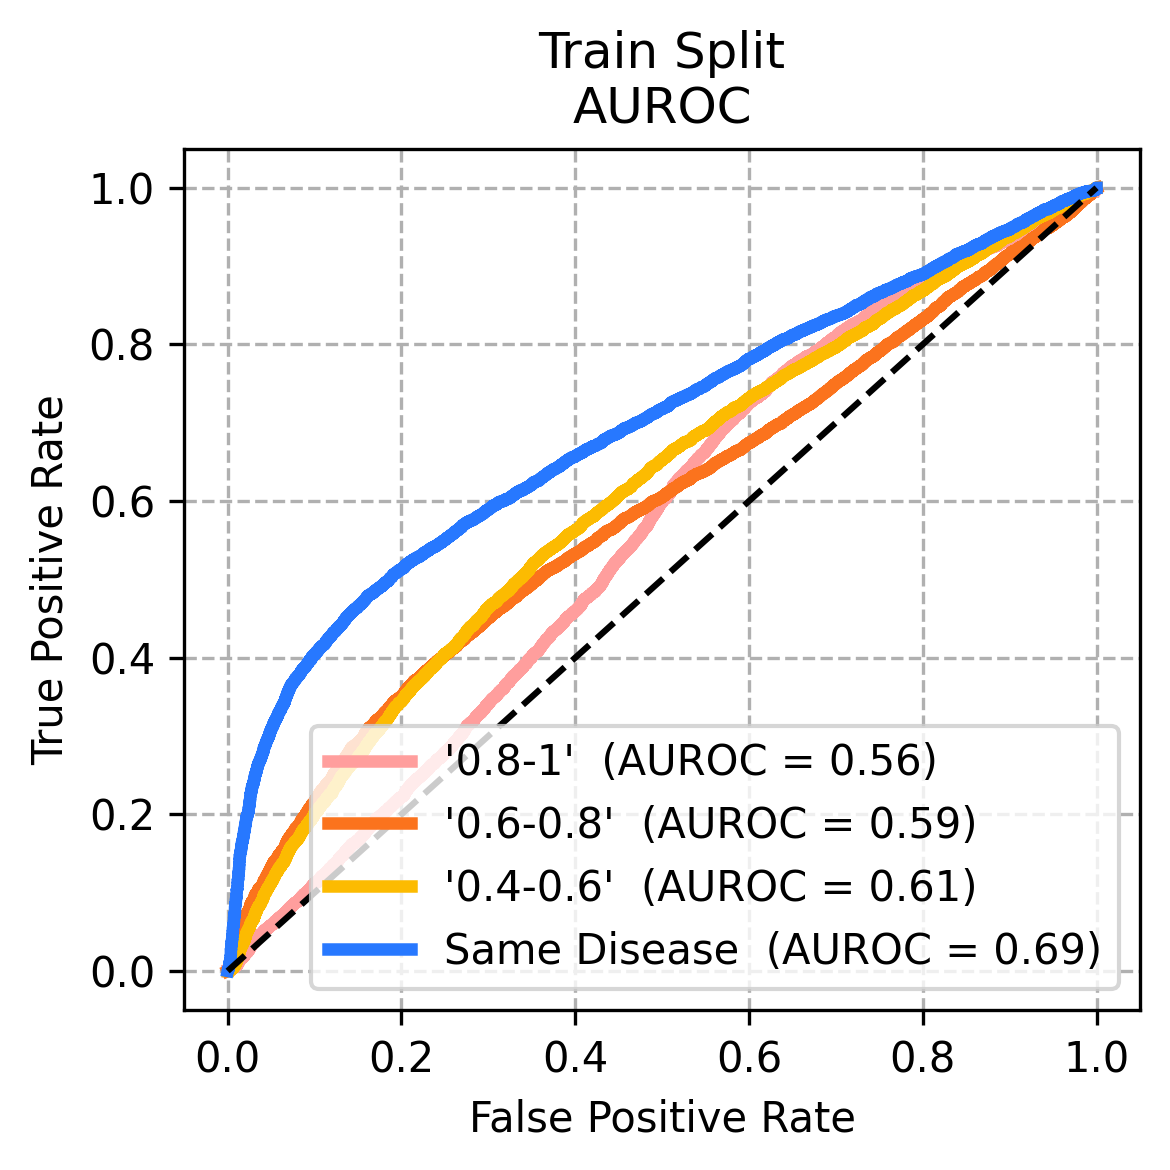

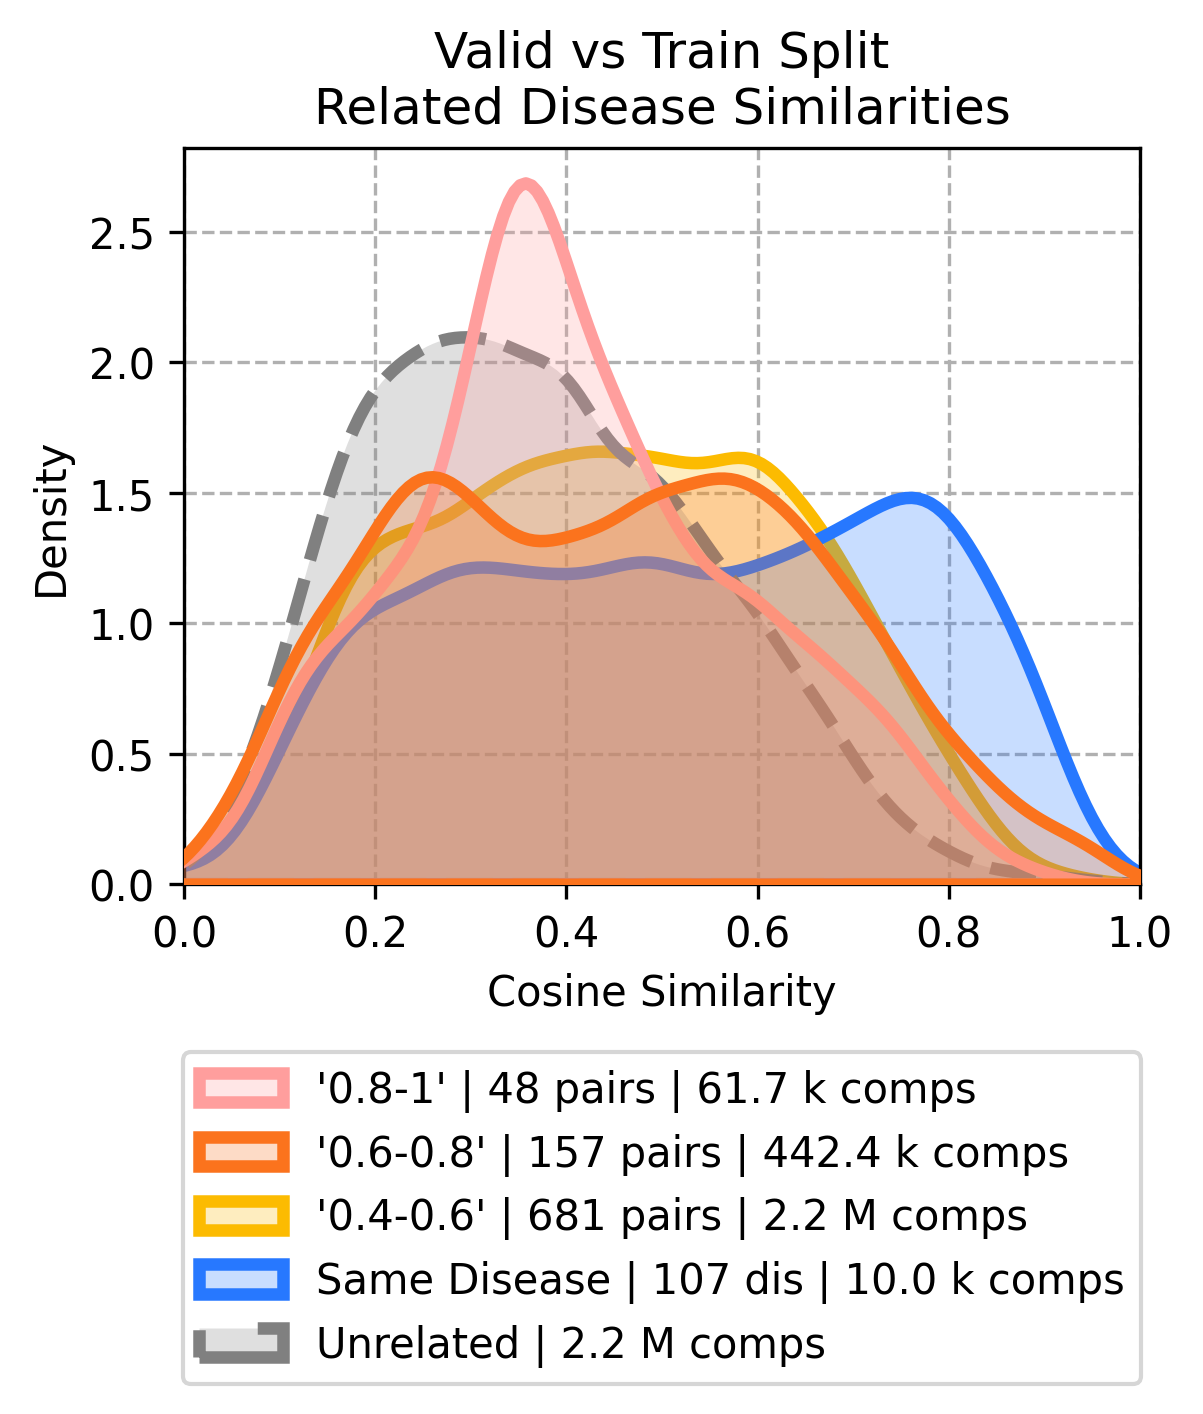

Nº of positive disease pairs: 61660
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 442381
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 2158448
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000


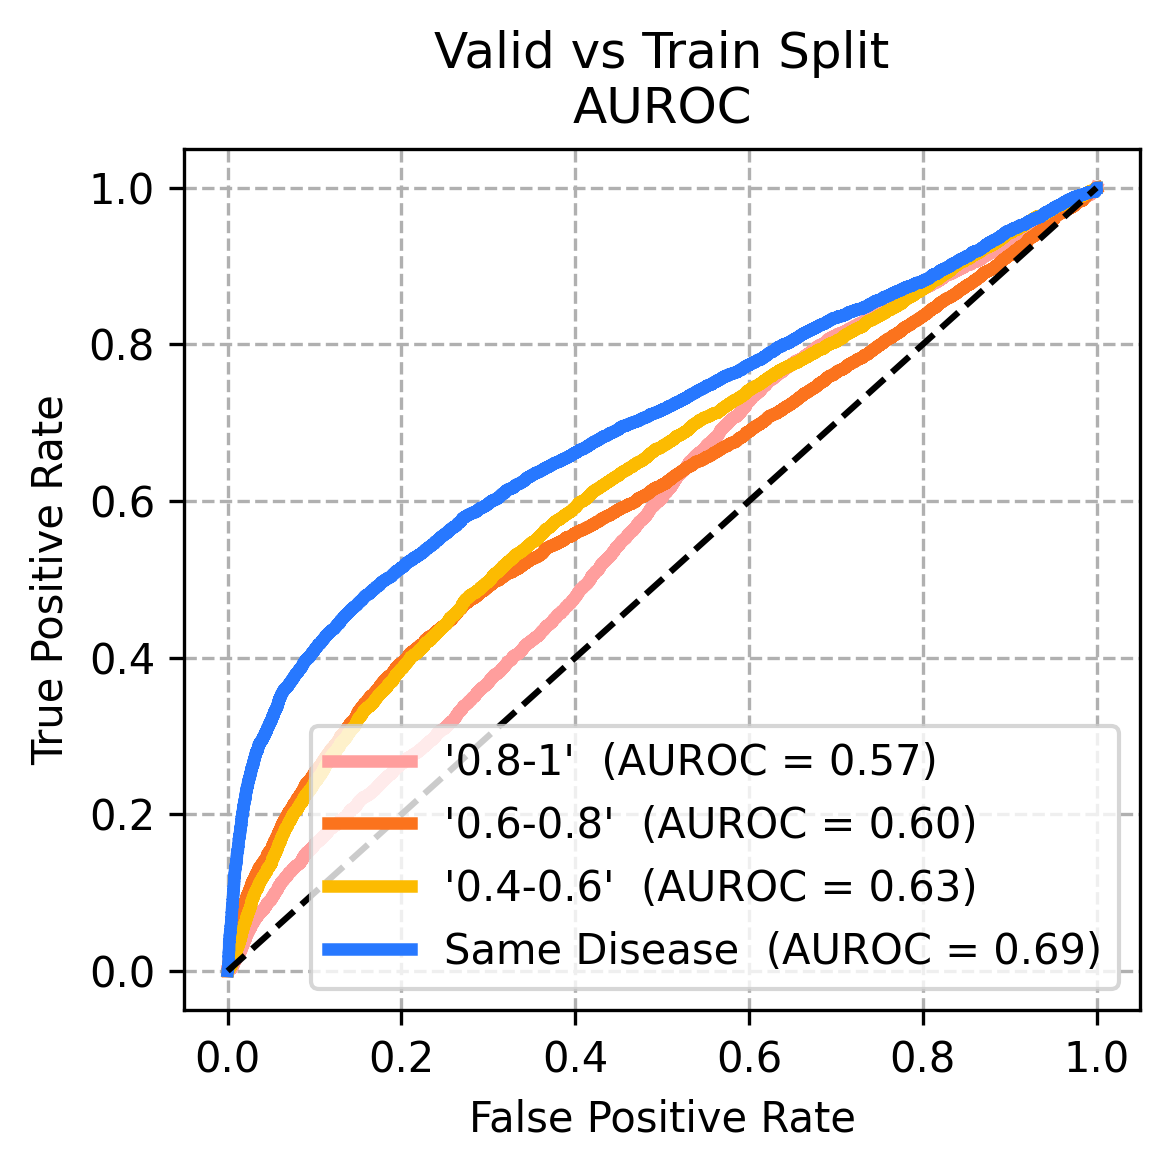

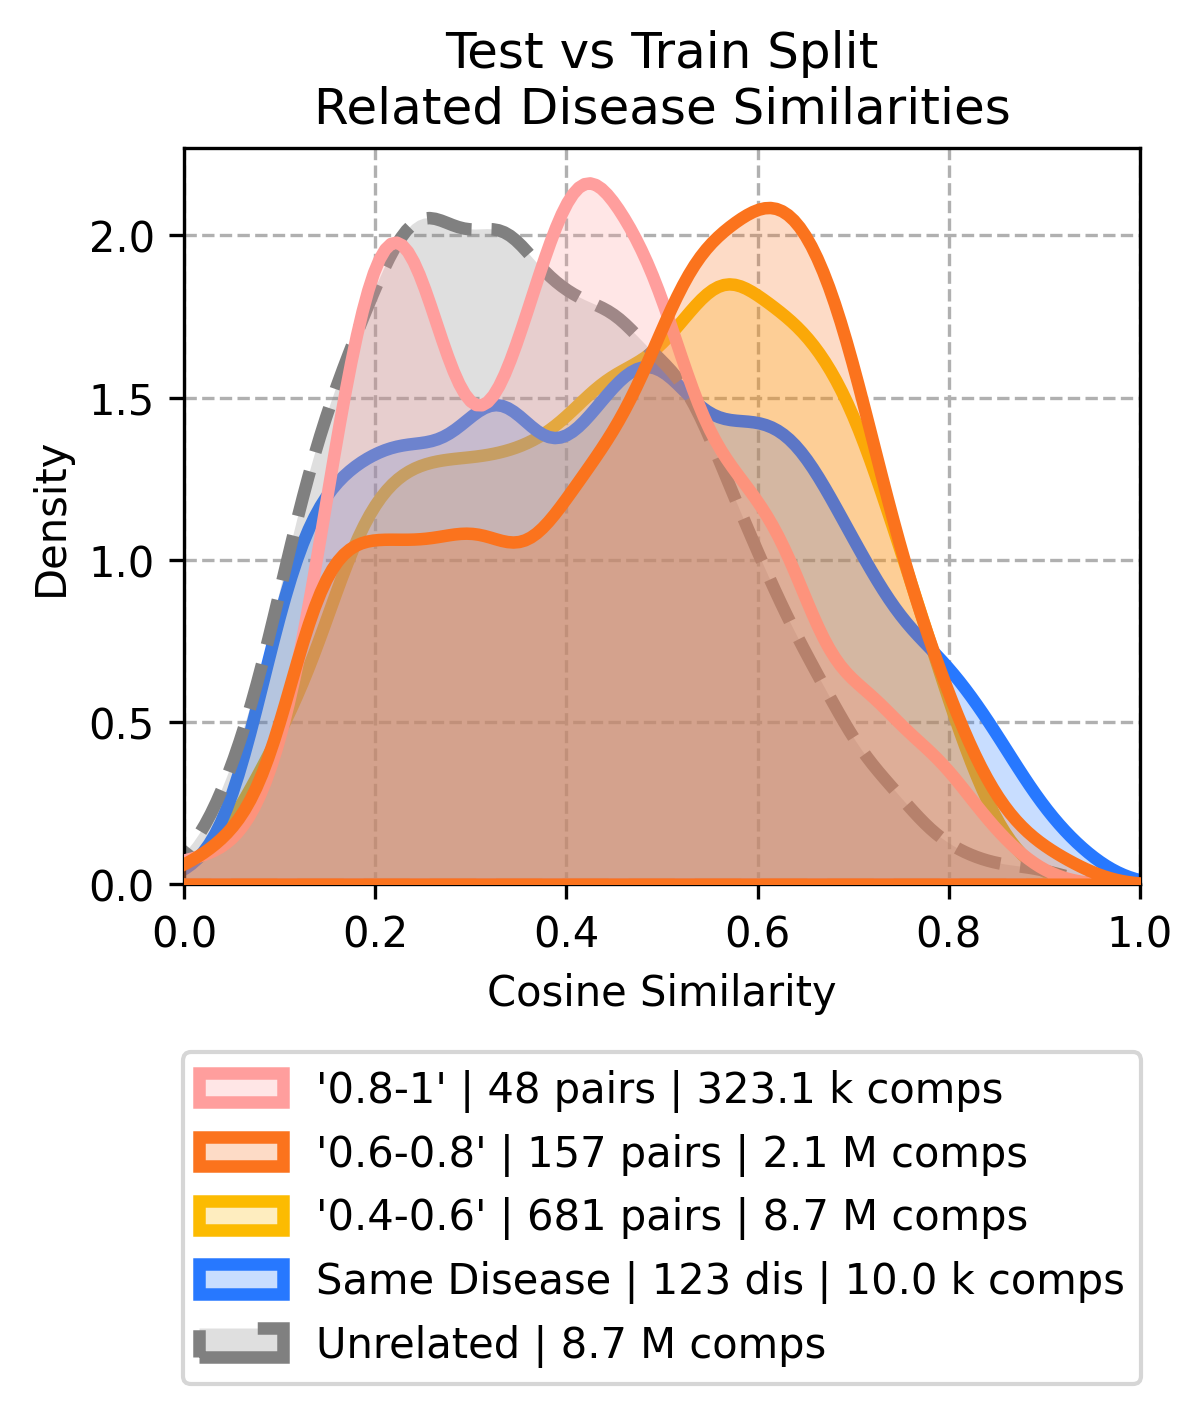

Nº of positive disease pairs: 323139
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 2078447
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 8682803
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000


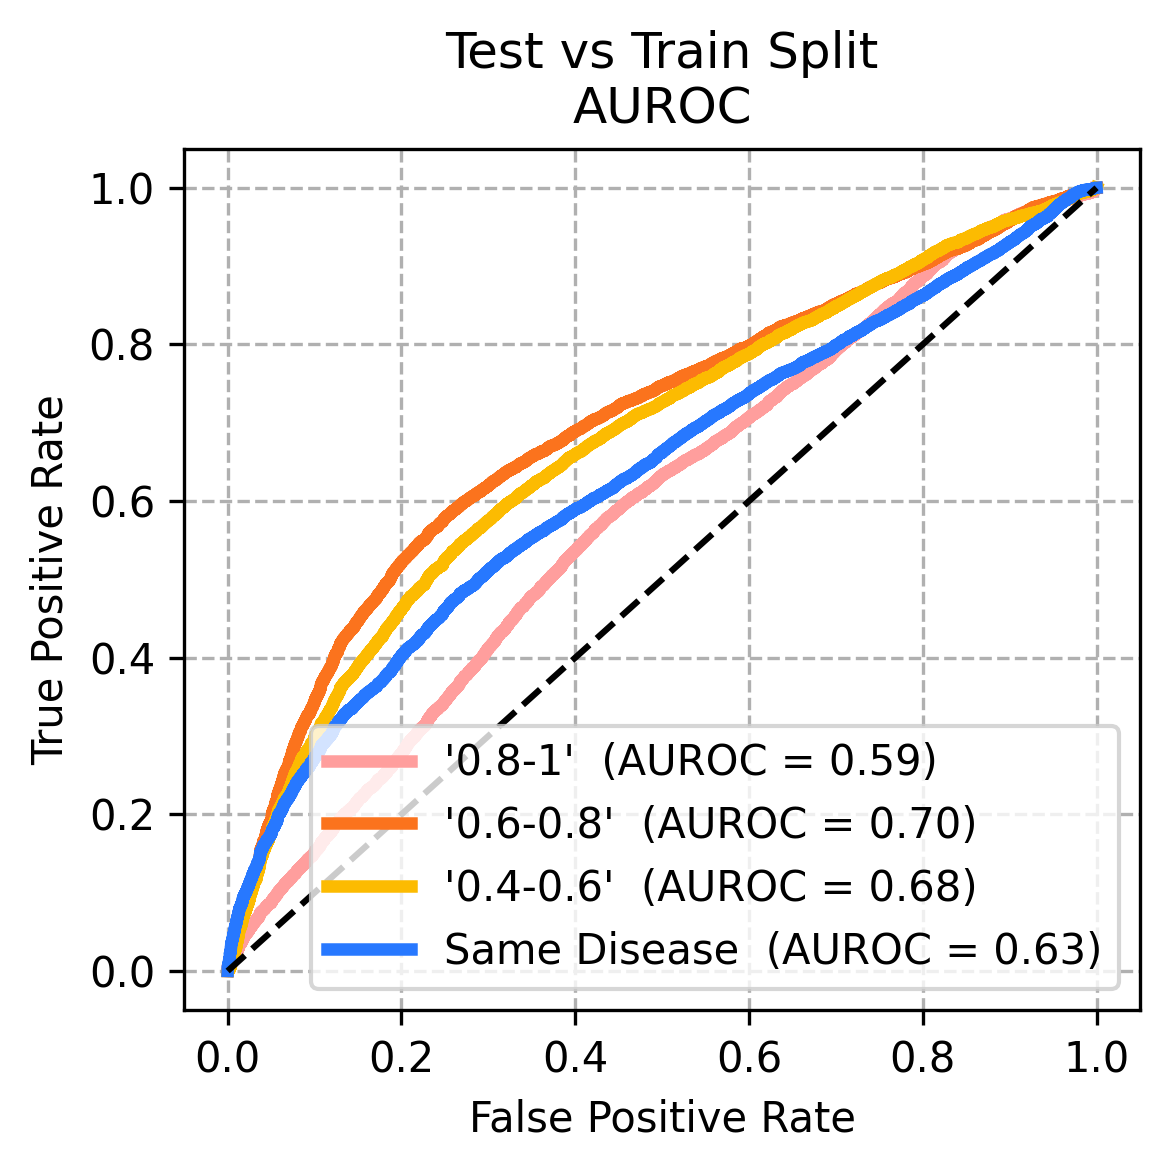

In [ ]:

dpi_val = 300
colors_val=["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]
# plot
# Type 1
# train
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_train_1.png"))
vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_train_1.png"))


# validation
vz.plot_kde(vl_s_all_1, labels=vl_l_all_1, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_valid_1.png"))
vz.plot_roc(vl_s_all_1[:-1], vl_s_unr, labels=vl_l_all_1, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_valid_1.png"))

# test
vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_1.png"))
vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_test_1.png"))


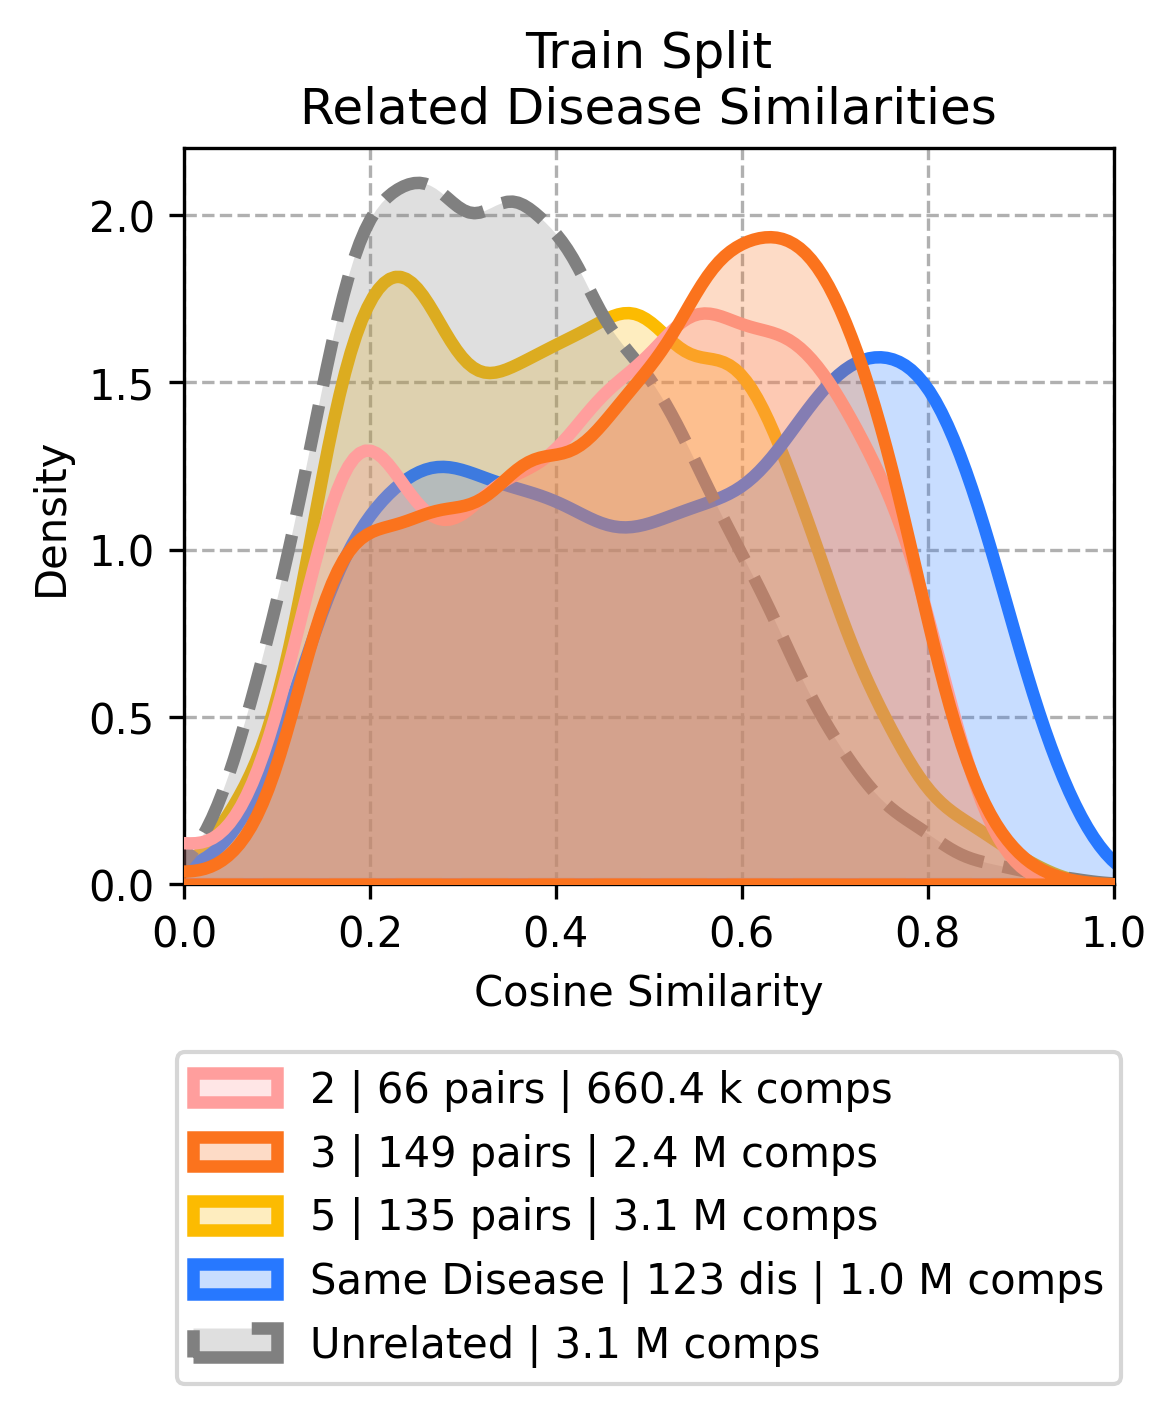

Nº of positive disease pairs: 660365
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 2381923
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 3076934
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1043867
Nº of positive disease pairs: 10000


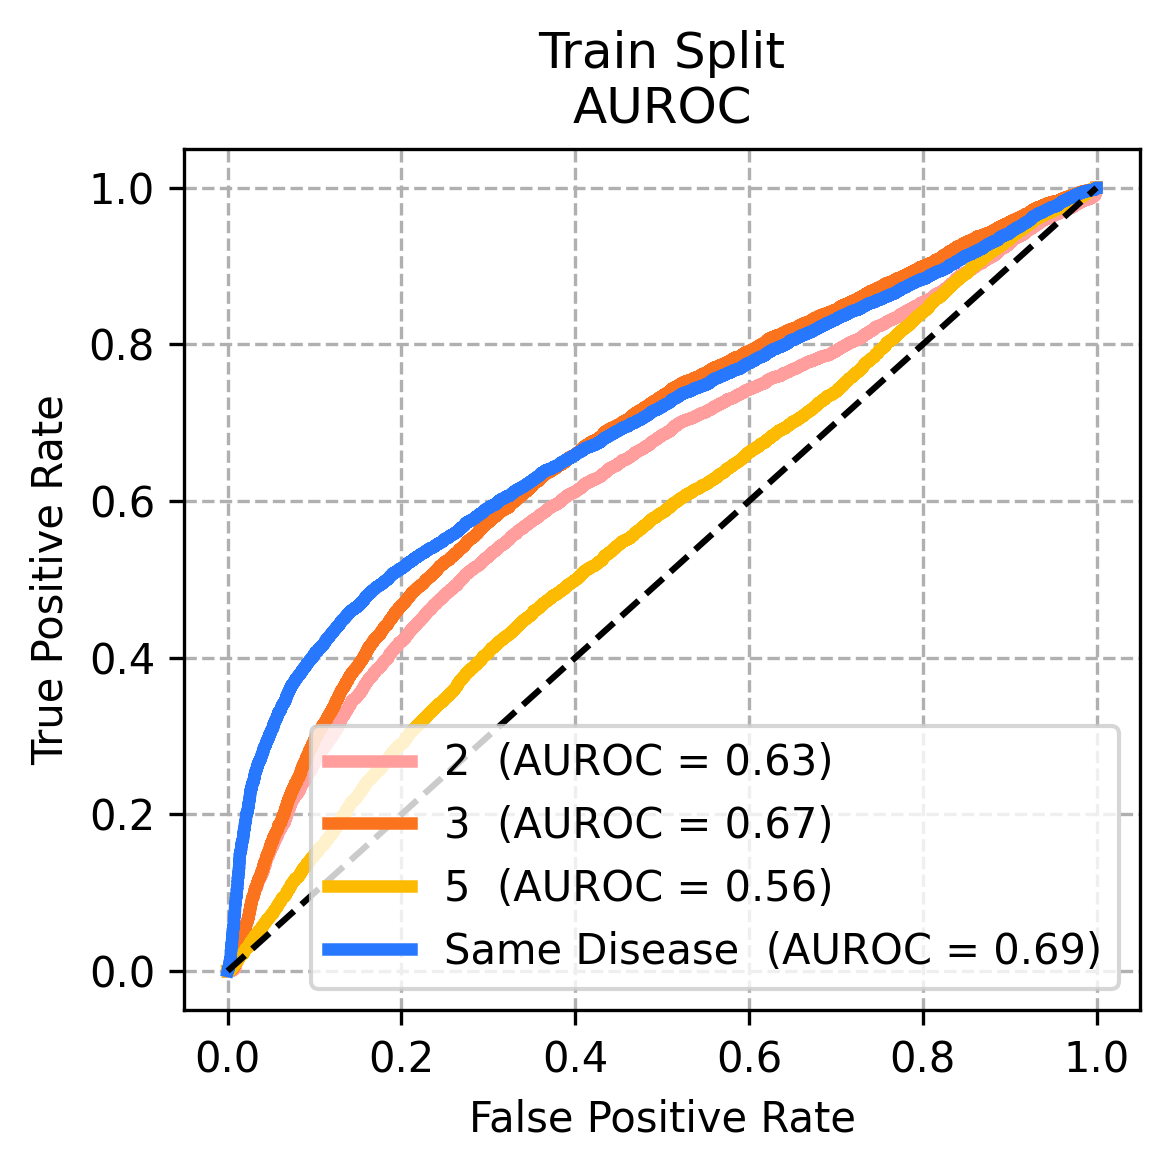

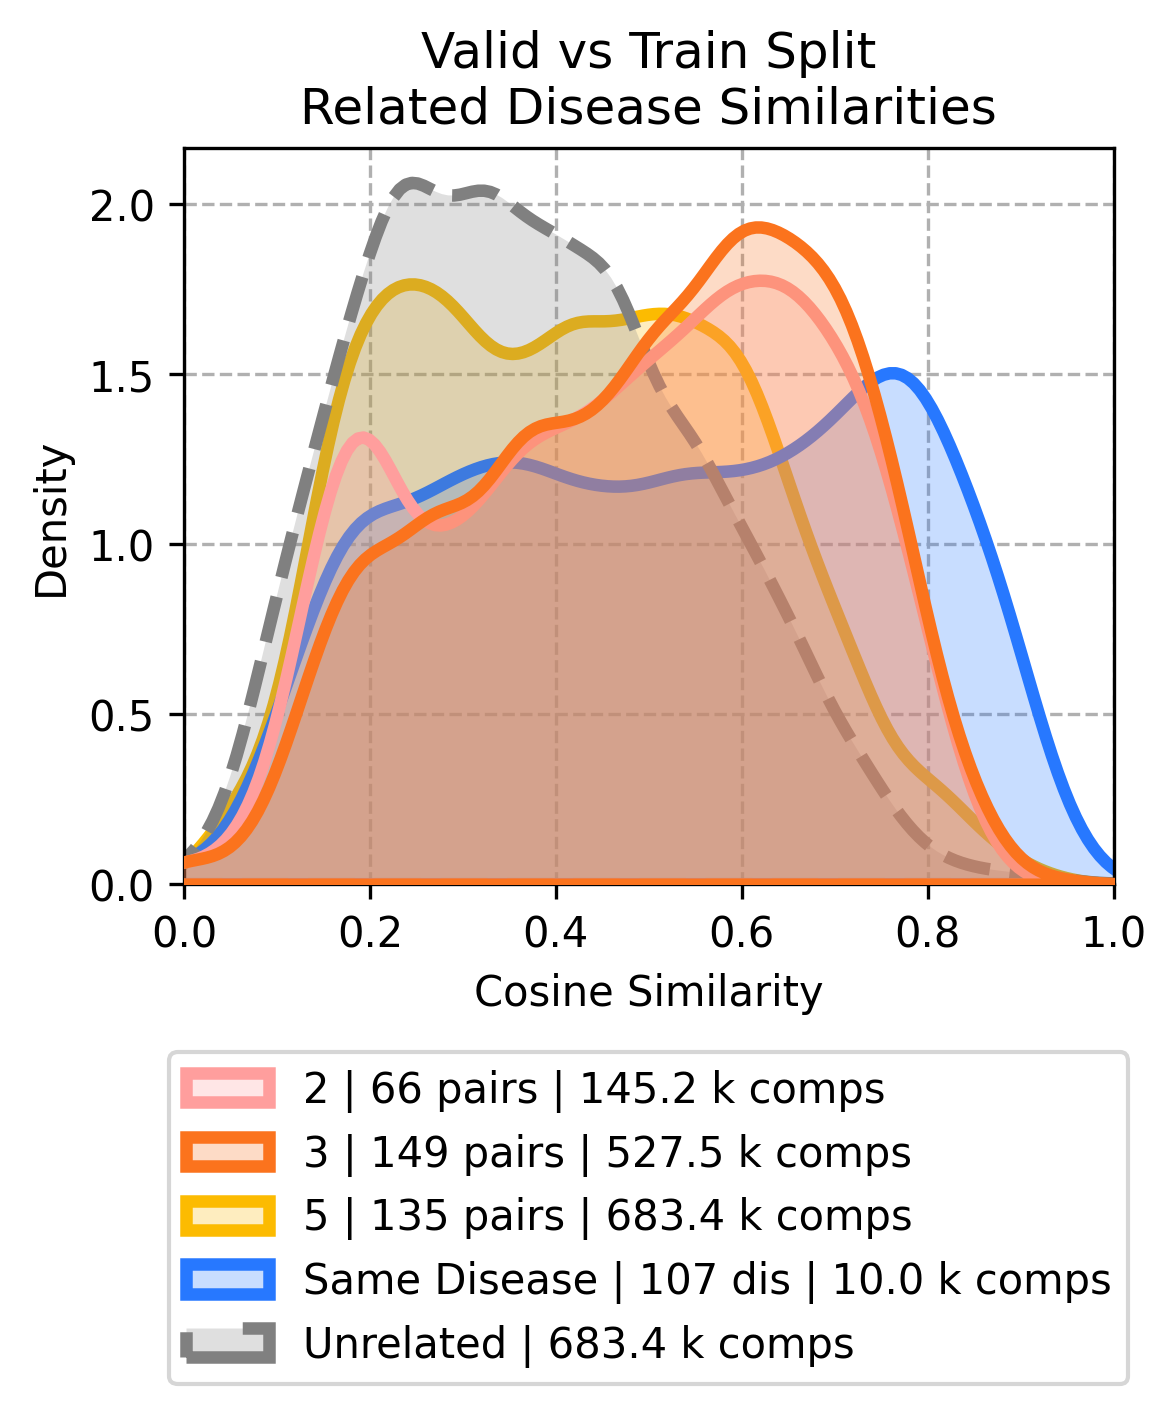

Nº of positive disease pairs: 145238
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 527530
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 683398
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000


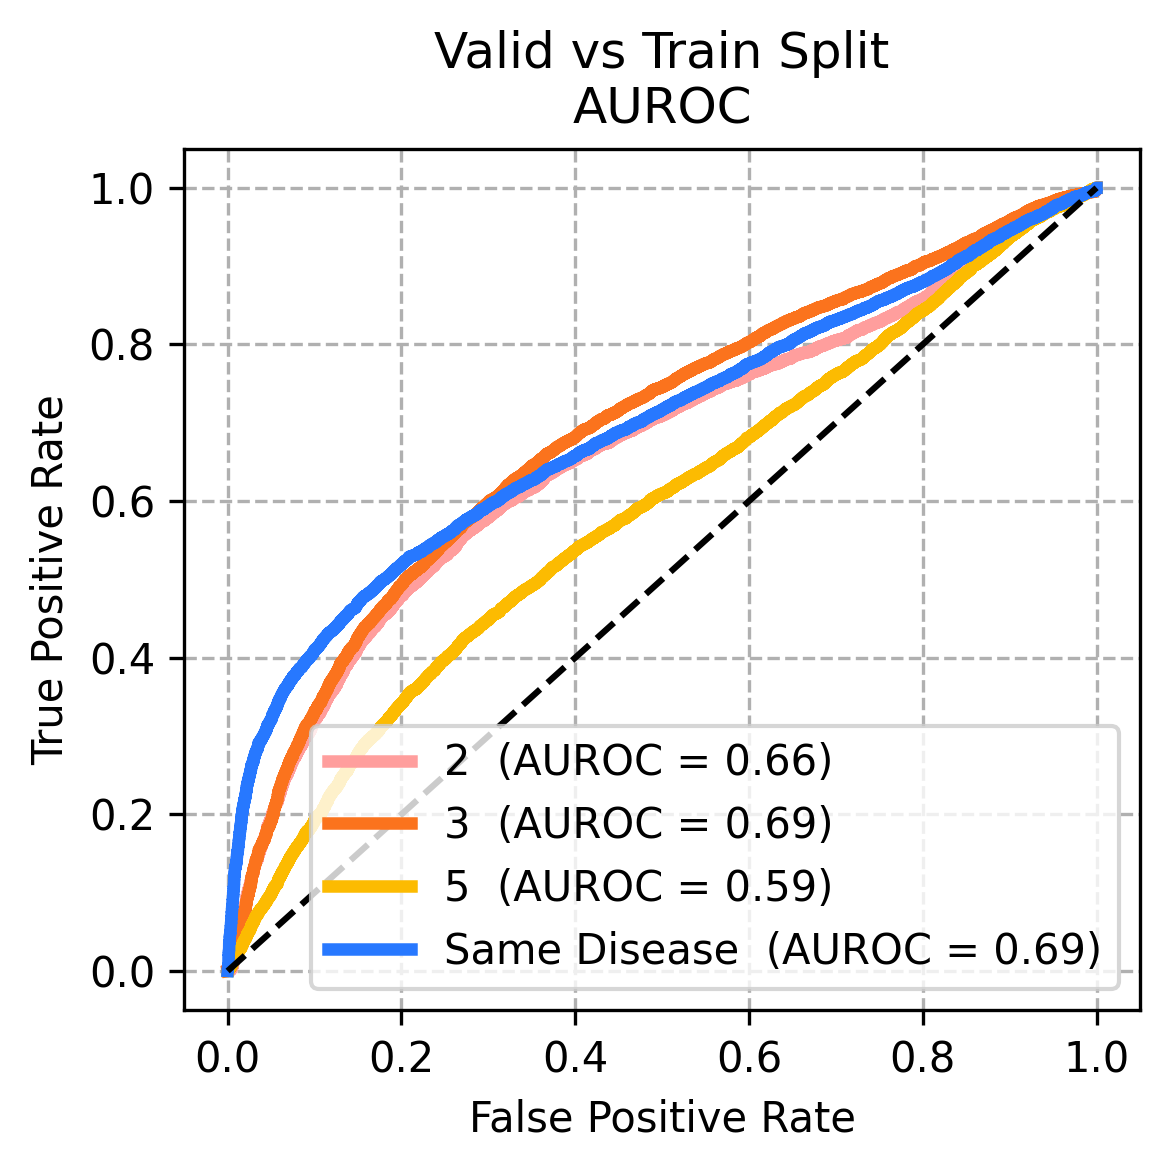

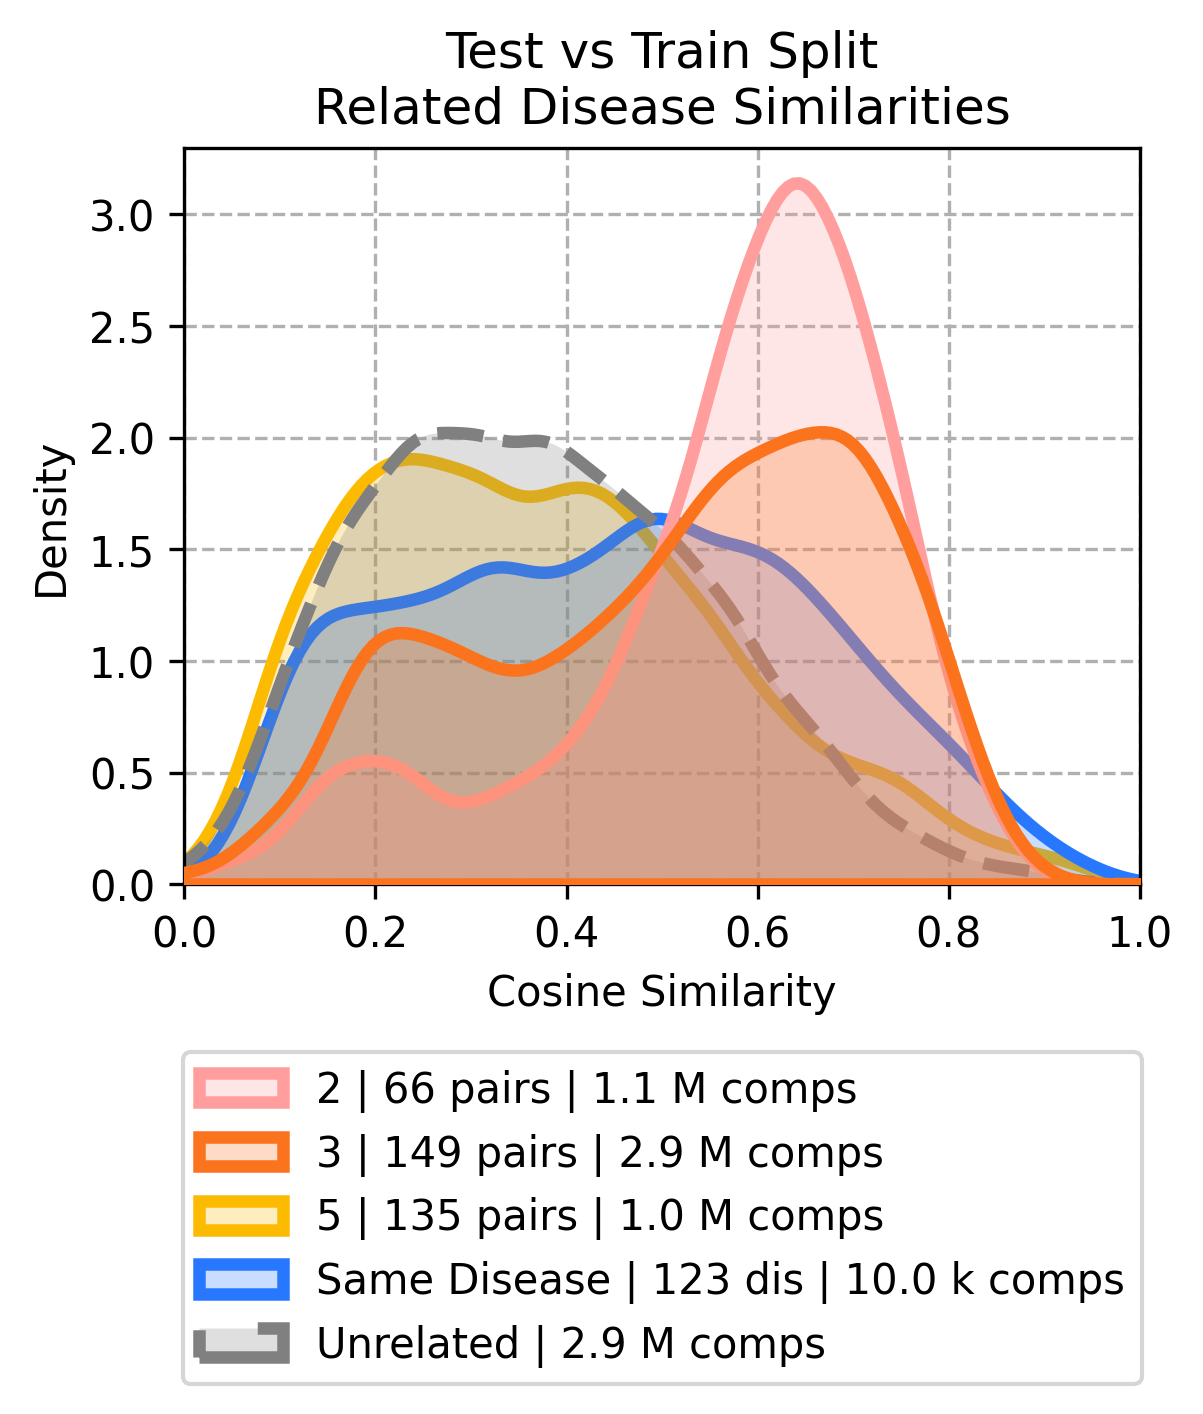

Nº of positive disease pairs: 1063495
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 2904473
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1005926
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 10000


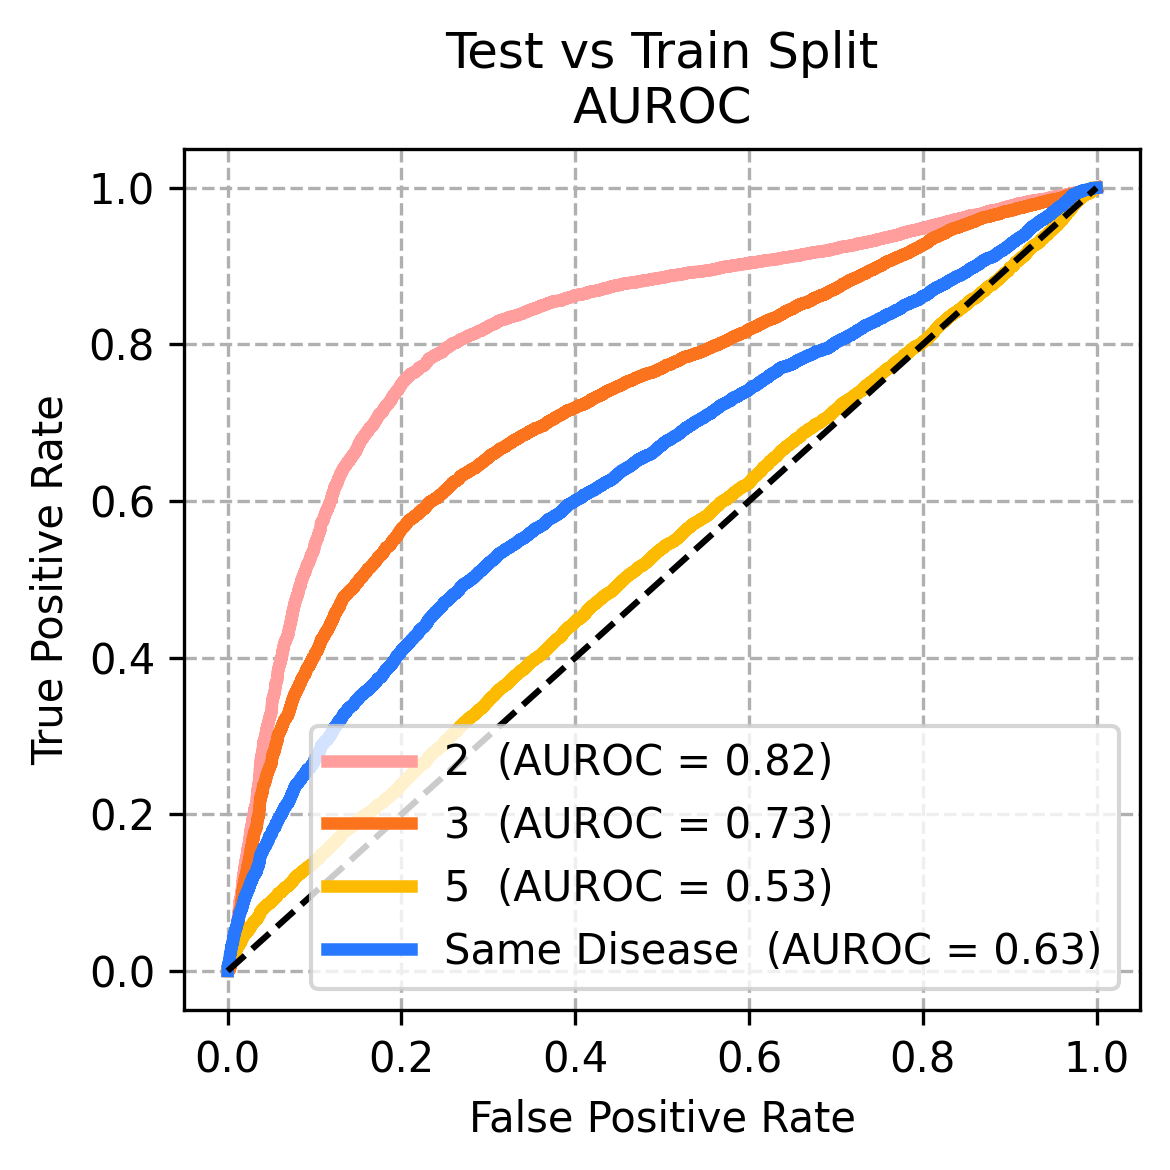

In [ ]:

# Type 2
# train
vz.plot_kde(tr_s_all_2, labels=tr_l_all_2, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_train_2.png"))
vz.plot_roc(tr_s_all_2[:-1], tr_s_unr, labels=tr_l_all_2, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_train_2.png"))

# validation
vz.plot_kde(vl_s_all_2, labels=vl_l_all_2, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_valid_2.png"))
vz.plot_roc(vl_s_all_2[:-1], vl_s_unr, labels=vl_l_all_2, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_valid_2.png"))

# test
vz.plot_kde(ts_s_all_2, labels=ts_l_all_2, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_2.png"))
vz.plot_roc(ts_s_all_2[:-1], ts_s_unr, labels=ts_l_all_2, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_test_2.png"))

In [ ]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)
    # if len(pos)==0:
    #     return np.nan
    # if len(pos) > min_size:
    #     pos = pos[random.sample(range(len(pos)), min_size)]
    # if len(neg) > min_size:
    #     neg = neg[random.sample(range(len(neg)), min_size)]

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def make_auroc_row(split_name:str, s_same_diff:np.array,  s_all_1:List,s_unr:np.array, ndigits:int=3):
    """
    s_all_2: list/tuple length 3 (e.g., Related 2/3/4)
    s_all_1: list/tuple length 3 (e.g., bins 0.8–1, 0.6–0.8, 0.4–0.6)
    """
    return pd.DataFrame({
        "Split": [split_name],
        "Same Disease Diff Dataset": [round(_auroc(s_same_diff, s_unr),ndigits=ndigits)],
        "Related 0.8–1": [round(_auroc(s_all_1[0], s_unr),ndigits=ndigits)],
        "Related 0.6–0.8": [round(_auroc(s_all_1[1], s_unr),ndigits=ndigits)],
        "Related 0.4–0.6": [round(_auroc(s_all_1[2], s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = make_auroc_row(
    "Train",
    tr_s_same_diff,       # expects [bin2, bin3, bin4]
    tr_s_all_1,            # expects [0.8–1, 0.6–0.8, 0.4–0.6]
    tr_s_unr
)

df_auroc_valid = make_auroc_row(
    "Valid",
    vl_s_same_diff,
    vl_s_all_1,
    vl_s_unr
)

df_auroc_test = make_auroc_row(
    "Test",
    ts_s_same_diff,
    ts_s_all_1,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
df_auroc.to_csv(os.path.join(output_dir, "gex_auroc_random_all.csv"), index=False)

df_auroc

Nº of positive disease pairs: 14905947
Nº of positive disease pairs: 6301503
Nº of positive disease pairs: 37439852
Nº of positive disease pairs: 141872457
Nº of positive disease pairs: 3320906
Nº of positive disease pairs: 1399364
Nº of positive disease pairs: 8332128
Nº of positive disease pairs: 31573952
Nº of positive disease pairs: 3045132
Nº of positive disease pairs: 2793832
Nº of positive disease pairs: 12360350
Nº of positive disease pairs: 48699217


,Split,Same Disease Diff Dataset,Related 0.8–1,Related 0.6–0.8,Related 0.4–0.6
0,Train,0.644,0.590,0.572,0.600
1,Valid,0.658,0.601,0.589,0.614
2,Test,0.631,0.606,0.594,0.574


In [ ]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)
    # if len(pos)==0:
    #     return np.nan
    # if len(pos) > min_size:
    #     pos = pos[random.sample(range(len(pos)), min_size)]
    # if len(neg) > min_size:
    #     neg = neg[random.sample(range(len(neg)), min_size)]

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def make_auroc_row(split_name:str, s_same_diff:np.array, s_all_2:List, s_all_1:List,s_ctrl:np.array, s_unr:np.array, ndigits:int=3):
    """
    s_all_2: list/tuple length 3 (e.g., Related 2/3/4)
    s_all_1: list/tuple length 3 (e.g., bins 0.8–1, 0.6–0.8, 0.4–0.6)
    """
    return pd.DataFrame({
        "Split": [split_name],
        "Same Disease Diff Dataset": [round(_auroc(s_same_diff, s_unr),ndigits=ndigits)],
        "Related 2": [round(_auroc(s_all_2[0], s_unr),ndigits=ndigits)],
        "Related 3": [round(_auroc(s_all_2[1], s_unr),ndigits=ndigits)],
        "Related 5": [round(_auroc(s_all_2[2], s_unr),ndigits=ndigits)],
        "Related 0.8–1": [round(_auroc(s_all_1[0], s_unr),ndigits=ndigits)],
        "Related 0.6–0.8": [round(_auroc(s_all_1[1], s_unr),ndigits=ndigits)],
        "Related 0.4–0.6": [round(_auroc(s_all_1[2], s_unr),ndigits=ndigits)],
        "Control" : [round(_auroc(s_ctrl, s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = make_auroc_row(
    "Train",
    tr_s_same_diff,
    tr_s_all_2,            # expects [bin2, bin3, bin4]
    tr_s_all_1,            # expects [0.8–1, 0.6–0.8, 0.4–0.6]
    tr_s_ctrl_diff,
    tr_s_unr
)

df_auroc_valid = make_auroc_row(
    "Valid",
    vl_s_same_diff,
    vl_s_all_2,
    vl_s_all_1,
    vl_s_ctrl_diff,
    vl_s_unr
)

df_auroc_test = make_auroc_row(
    "Test",
    ts_s_same_diff,
    ts_s_all_2,
    ts_s_all_1,
    ts_s_ctrl_diff,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
df_auroc.to_csv(os.path.join(output_dir, "gex_auroc_random_all.csv"), index=False)

df_auroc

Nº of positive disease pairs: 1043867
Nº of positive disease pairs: 660365
Nº of positive disease pairs: 2381923
Nº of positive disease pairs: 3076934
Nº of positive disease pairs: 279956
Nº of positive disease pairs: 1994824
Nº of positive disease pairs: 9716963
Nº of positive disease pairs: 740687
Nº of positive disease pairs: 235095
Nº of positive disease pairs: 145238
Nº of positive disease pairs: 527530
Nº of positive disease pairs: 683398
Nº of positive disease pairs: 61660
Nº of positive disease pairs: 442381
Nº of positive disease pairs: 2158448
Nº of positive disease pairs: 126761
Nº of positive disease pairs: 279567
Nº of positive disease pairs: 1063495
Nº of positive disease pairs: 2904473
Nº of positive disease pairs: 1005926
Nº of positive disease pairs: 323139
Nº of positive disease pairs: 2078447
Nº of positive disease pairs: 8682803
Nº of positive disease pairs: 284177


,Split,Same Disease Diff Dataset,Related 2,Related 3,Related 5,Related 0.8–1,Related 0.6–0.8,Related 0.4–0.6,Control
0,Train,0.690,0.637,0.674,0.563,0.560,0.585,0.605,0.660
1,Valid,0.696,0.664,0.696,0.582,0.575,0.608,0.625,0.694
2,Test,0.633,0.815,0.723,0.528,0.590,0.694,0.676,0.509


In [ ]:
high_vals = (ts_s_all_1[1][ts_s_all_1[1]>0.8])

np.argwhere(c_matrix_test_vs_train_ == high_vals[15])

array([[2228, 1862],
       [2228, 5420]])

In [ ]:
adata_qry = adata_test
adata_ref = adata_train
c_matrix = c_matrix_test_vs_train_
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.8-1'","'0.6-0.8'","'0.4-0.6'"]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins

labels = _bin_labels

# select datasets & do_ids
do_ids_qry = adata_qry.obs["do_id"].values
datasets_qry = adata_qry.obs["dataset"].values

do_ids_ref = adata_ref.obs["do_id"].values
datasets_ref = adata_ref.obs["dataset"].values

# get pairs    
for _, label_i in enumerate([labels[1]]):
    _df_related = df_related.query(f"shortest_path_length == {label_i}")
    print(f"[SP {label_i}] Nº of related disease pairs: {len(_df_related)}")

    # get related pairs
    related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_related["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
    print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

    _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]


[SP '0.6-0.8'] Nº of related disease pairs: 157


100%|██████████| 157/157 [00:04<00:00, 33.26it/s]


Nº of related disease pairs for '0.6-0.8': 2078447


In [ ]:
top_scores = np.argwhere(_c_related>0.8)

top_idxs = related_idxs[top_scores.flatten()] 

In [ ]:
adata_qry.obs["doid_id"][top_idxs[:,0]]

6158    DOID:3905
6158    DOID:3905
6158    DOID:3905
6158    DOID:3905
6158    DOID:3905
          ...    
2881    DOID:9074
2881    DOID:9074
2881    DOID:9074
2881    DOID:9074
2881    DOID:9074
Name: doid_id, Length: 62350, dtype: category
Categories (124, object): ['Control', 'DOID:235', 'DOID:289', 'DOID:332', ..., 'DOID:0060161', 'DOID:0060488', 'DOID:0080199', 'DOID:0081087']

In [ ]:
adata_orig.obs["tissue"]

0         Retina
1         Retina
2         Retina
3         Retina
4         Retina
           ...  
118187       nan
118188       nan
118189       nan
118190       nan
118191       nan
Name: tissue, Length: 25587, dtype: category
Categories (119, object): ['Adductor muscle', 'Adipose tissue', 'Airway epithelium', 'Airway smooth muscle', ..., 'White matter', 'Whole Blood', 'Whole blood', 'nan']

In [ ]:
top_pairs = pd.DataFrame({"Query_idx":adata_qry.obs["doid_id"][top_idxs[:,0]].to_list(),"Ref_idx":adata_ref.obs["doid_id"][top_idxs[:,1]].to_list(), "Score":_c_related[top_scores.flatten()]})

In [ ]:
top_pairs

,Query_idx,Ref_idx,Score
0,DOID:3905,DOID:0050156,0.804726
1,DOID:3905,DOID:0050156,0.829817
2,DOID:3905,DOID:0050156,0.862477
3,DOID:3905,DOID:0050156,0.805206
4,DOID:3905,DOID:0050156,0.808850
...,...,...,...
62345,DOID:9074,DOID:9744,0.817365
62346,DOID:9074,DOID:9744,0.849838
62347,DOID:9074,DOID:9744,0.876720
62348,DOID:9074,DOID:9744,0.867972


In [ ]:
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

In [ ]:
top_pairs["Query_dis"] = top_pairs["Query_idx"].map(doid_to_term)
top_pairs["Ref_dis"] = top_pairs["Ref_idx"].map(doid_to_term)

In [ ]:
do_df_ic_query.query("do2=='DOID:1520' & do1=='DOID:0080199'")

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
27643501,DOID:0080199,DOID:1520,"[DOID:0080199, DOID:1520]",8.382483,0.784594,4.602737,DOID:9256,3


In [ ]:
top_pairs

,Query_idx,Ref_idx,Score,Query_dis,Ref_dis
0,DOID:3905,DOID:0050156,0.804726,lung carcinoma,idiopathic pulmonary fibrosis
1,DOID:3905,DOID:0050156,0.829817,lung carcinoma,idiopathic pulmonary fibrosis
2,DOID:3905,DOID:0050156,0.862477,lung carcinoma,idiopathic pulmonary fibrosis
3,DOID:3905,DOID:0050156,0.805206,lung carcinoma,idiopathic pulmonary fibrosis
4,DOID:3905,DOID:0050156,0.808850,lung carcinoma,idiopathic pulmonary fibrosis
...,...,...,...,...,...
62345,DOID:9074,DOID:9744,0.817365,systemic lupus erythematosus,type 1 diabetes mellitus
62346,DOID:9074,DOID:9744,0.849838,systemic lupus erythematosus,type 1 diabetes mellitus
62347,DOID:9074,DOID:9744,0.876720,systemic lupus erythematosus,type 1 diabetes mellitus
62348,DOID:9074,DOID:9744,0.867972,systemic lupus erythematosus,type 1 diabetes mellitus


In [ ]:
adata_qry.obs["tissue"]

0       Retina
1       Retina
2       Retina
3       Retina
4       Retina
         ...  
6160     Blood
6161     Blood
6162     Blood
6163     Blood
6164     Blood
Name: tissue, Length: 6165, dtype: category
Categories (44, object): ['Bladder', 'Blood', 'Bone marrow', 'Brain', ..., 'Umbilical cord', 'Vastus lateralis', 'Whole blood', 'nan']

In [ ]:

c_all = list()
w_all = list()
l_all = list()
_sample_sizes = list()
for _, label_i in enumerate(labels):
    _df_related = df_related.query(f"shortest_path_length == {label_i}")
    print(f"[SP {label_i}] Nº of related disease pairs: {len(_df_related)}")

    # get related pairs
    related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_related["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
    print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

    # convert label to weights - all pairs add to 1
    _w_related = vz.convert_labels_to_weights(_l_related)

    if sample & (len(related_idxs) > sample):
        _sample_i = random.sample(range(len(related_idxs)), sample)
        related_idxs = related_idxs[_sample_i]
        _w_related = _w_related[_sample_i]

    # retrieve similarities
    _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

    # append values
    c_all.append(_c_related)
    w_all.append(_w_related)
    _sample_sizes.append(len(_c_related))

    # append labels
    l_all.append(f"{label_i} | {len(_df_related)} pairs | {fmt(len(_c_related))} comps",)


# get sample of SAME DISEASE
same_idxs, _l_same = get_doid_idxs_single_set(do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)    
_w_same = _convert_labels_to_weights(_l_same)
if sample:
    _sample_i = random.sample(range(len(same_idxs)), sample)
    same_idxs = same_idxs[_sample_i]
    _w_same = _w_same[_sample_i]

_c_same = c_matrix[same_idxs[:, 0], same_idxs[:, 1]]
c_all.append(_c_same)
w_all.append(_w_same)
l_all.append(f"Same Disease | {len(set(do_ids_qry)-set(['Control']))} dis | {fmt(len(_c_same))} comps")

# get sample of unrelated pairs
_sample_i = random.sample(range(len(unrelated_universe)), max(_sample_sizes))
_unrelated_sample = unrelated_universe[_sample_i]
print(f"Nº of unrelated disease pairs: {len(_unrelated_sample)}")

_s_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
_w_unrelated = np.ones(len(_s_unrelated))   # do not weight - they are random - no groupings
c_all.append(_s_unrelated)
w_all.append(_w_unrelated)
l_all.append(f"Unrelated | {fmt(len(_s_unrelated))} comps")


[SP '0.8-1'] Nº of related disease pairs: 48


100%|██████████| 48/48 [00:00<00:00, 62.31it/s]


Nº of related disease pairs for '0.8-1': 323139


AttributeError: module 'src.utils.viz' has no attribute 'convert_labels_to_weights'

In [ ]:
from matplotlib.ticker import EngFormatter


def get_related_tiss_sim_splits(
    adata_qry, adata_ref, c_matrix, sample:int=None
):
    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    tiss_ids_qry = adata_qry.obs["tissue"].values
    datasets_qry = adata_qry.obs["dataset"].values

    tiss_ids_ref = adata_ref.obs["tissue"].values
    datasets_ref = adata_ref.obs["dataset"].values

    # get random pairs
    rnd_1 = random.choices(range(len(tiss_ids_qry)), k=10000000)
    rnd_2 = random.choices(range(len(tiss_ids_ref)), k=10000000)
    _random_sample = np.array(list(zip(rnd_1, rnd_2)))

    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()

    # get sample of SAME DISEASE
    same_idxs, _l_same = vz.get_doid_idxs_single_set(tiss_ids_qry, tiss_ids_ref, datasets_qry, datasets_ref, return_weights=True)    
    _w_same = vz._convert_labels_to_weights(_l_same)
    if sample:
        _sample_i = random.sample(range(len(same_idxs)), sample)
        same_idxs = same_idxs[_sample_i]
        _w_same = _w_same[_sample_i]

    _c_same = c_matrix[same_idxs[:, 0], same_idxs[:, 1]]
    c_all.append(_c_same)
    w_all.append(_w_same)
    l_all.append(f"Same Tissue | {len(set(tiss_ids_qry)-set(['Control']))} dis | {fmt(len(_c_same))} comps")

    # get sample of random pairs    
    _s_random = c_matrix[_random_sample[:, 0], _random_sample[:, 1]]
    _w_random = np.ones(len(_s_random))   # do not weight - they are random - no groupings
    c_all.append(_s_random)
    w_all.append(_w_random)
    l_all.append(f"Random | {fmt(len(_s_random))} comps")

    return c_all, w_all, l_all

tr_tiss_c_all, tr_tiss_w_all, tr_tiss_l_all = get_related_tiss_sim_splits(
    adata_train, adata_train, c_matrix_train, sample=1000
)

valid_tiss_c_all, valid_tiss_w_all, valid_tiss_l_all = get_related_tiss_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train_, sample=1000
)

ts_tiss_c_all, ts_tiss_w_all, ts_tiss_l_all = get_related_tiss_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train_, sample=1000
)

Nº of diseases: 105


100%|██████████| 105/105 [00:14<00:00,  7.13it/s]


Nº of diseases: 94


100%|██████████| 94/94 [00:01<00:00, 56.12it/s]


Nº of diseases: 43


100%|██████████| 43/43 [00:03<00:00, 11.81it/s]


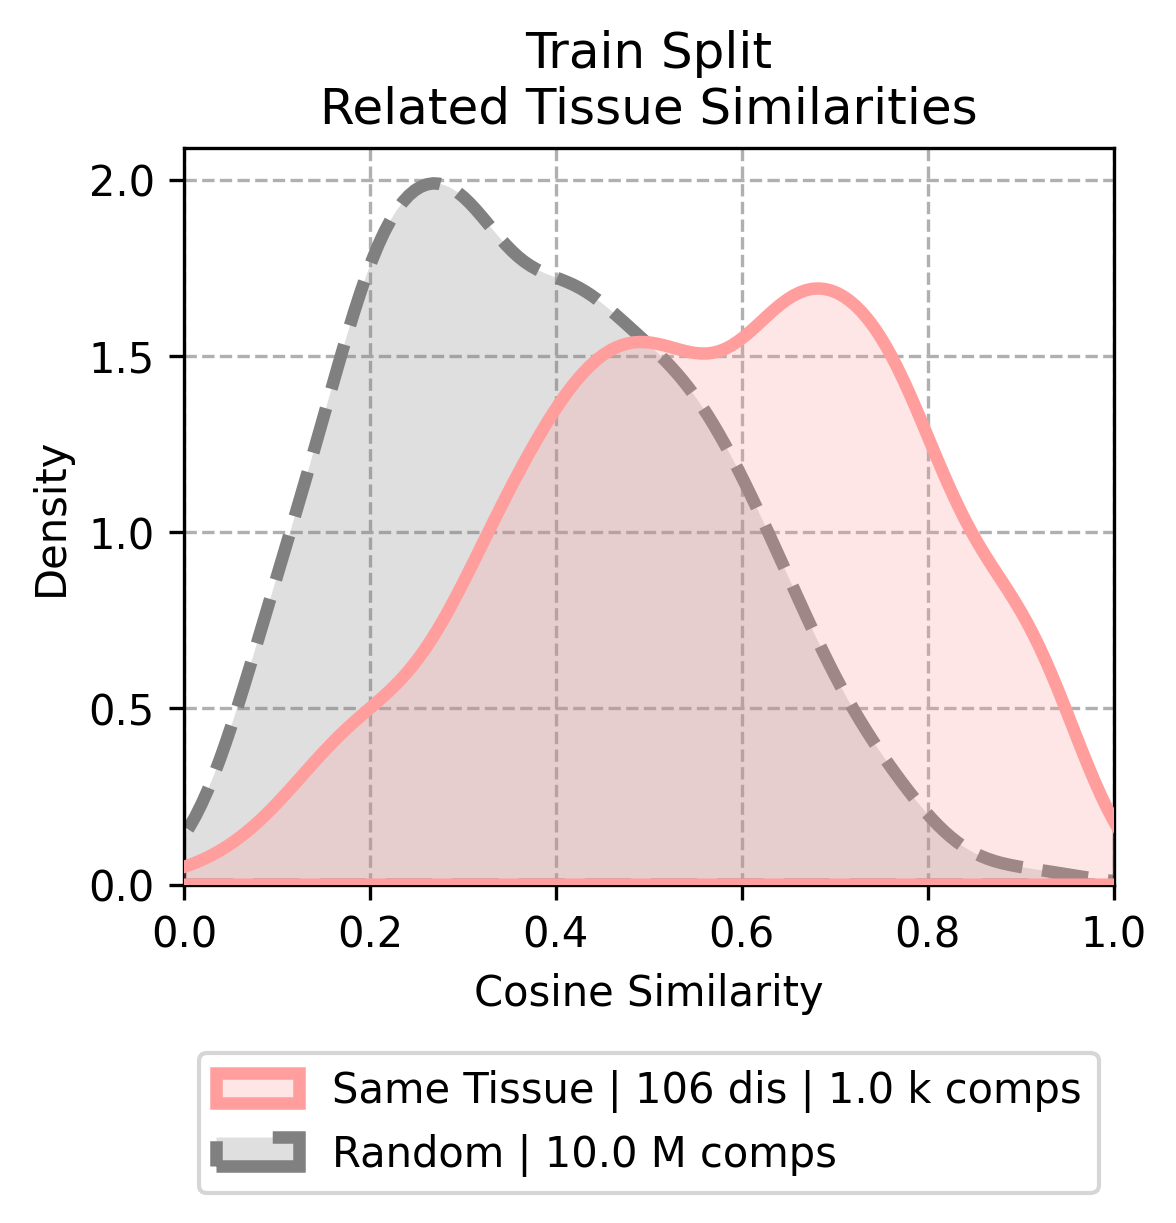

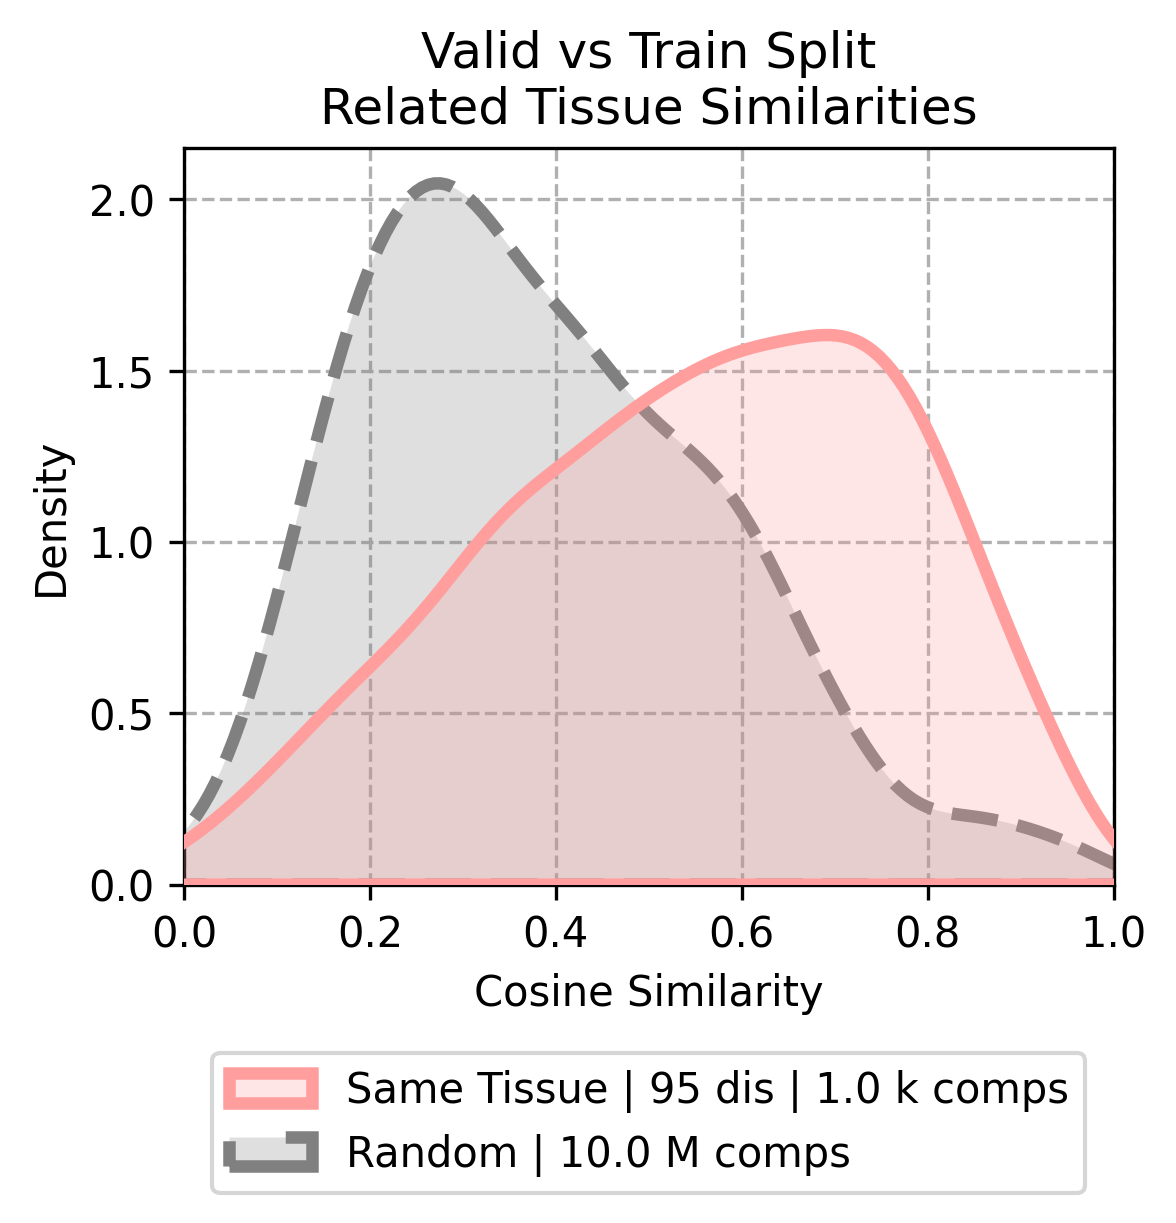

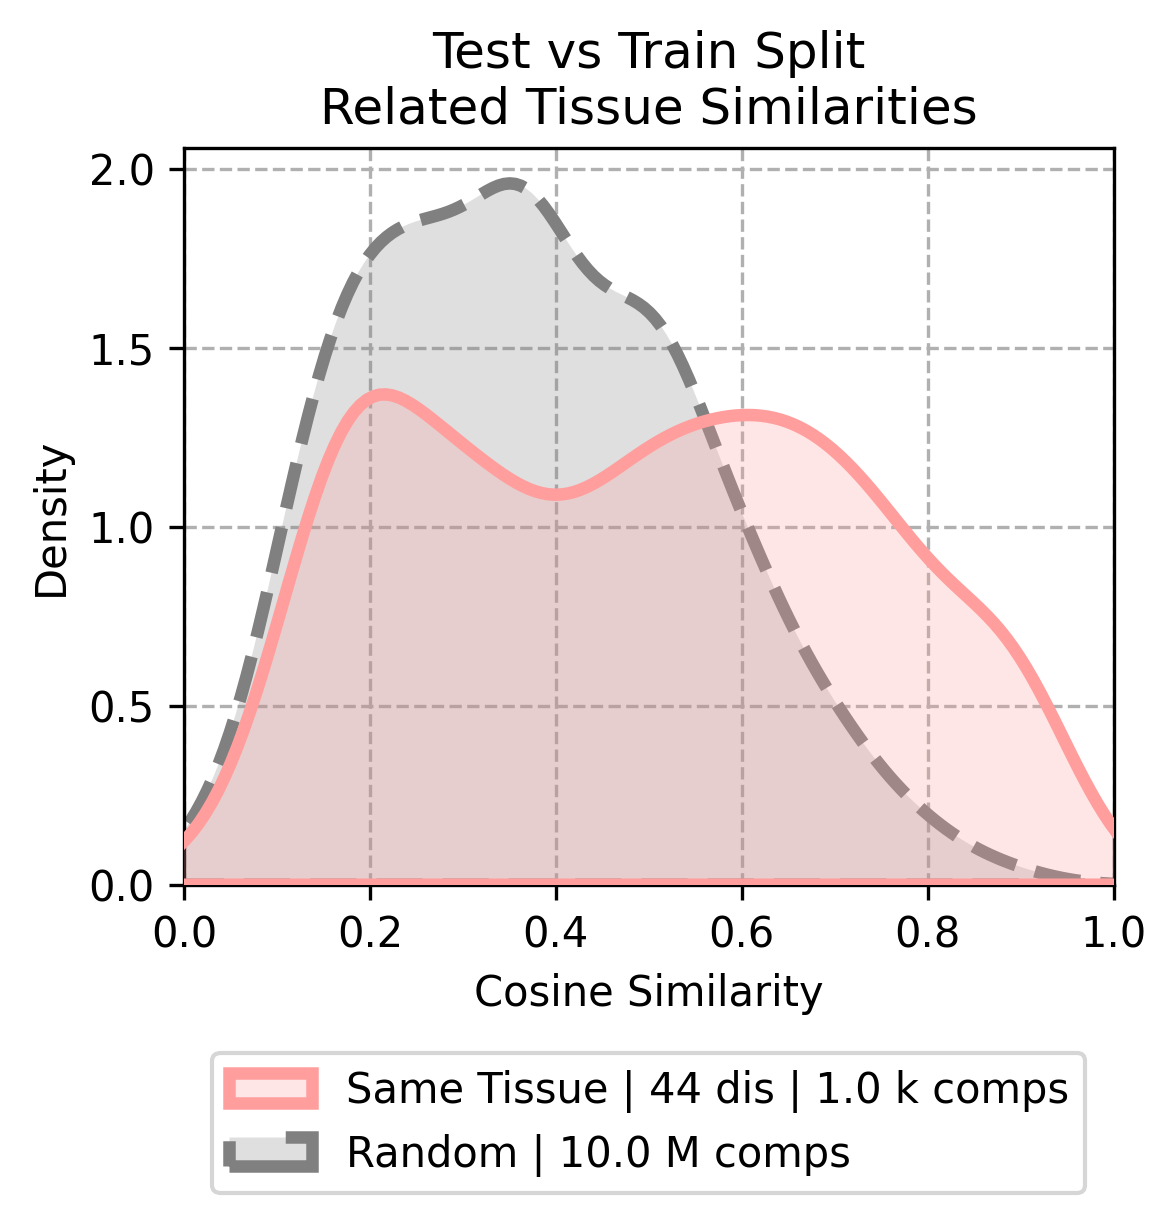

In [ ]:
import importlib
importlib.reload(vz)
vz.plot_kde(tr_tiss_c_all, labels=tr_tiss_l_all, colors=colors_val, title="Train Split\nRelated Tissue Similarities", metric="P.Correlation", weights=None, sample=1000, dpi=300, )
vz.plot_kde(valid_tiss_c_all, labels=valid_tiss_l_all, colors=colors_val, title="Valid vs Train Split\nRelated Tissue Similarities", metric="P.Correlation", weights=None, sample=1000, dpi=300, )
vz.plot_kde(ts_tiss_c_all, labels=ts_tiss_l_all, colors=colors_val, title="Test vs Train Split\nRelated Tissue Similarities", metric="P.Correlation", weights=None, sample=1000, dpi=300, )

# 5. Benchmark Comorbidity Similarity

In [8]:
# imports


# variables
com_tsv_path = "/aloy/home/ddalton/databases/HuDiNe/AllNet5.tsv"


# functions

## 5.1 Load Comorbidity Pairs

In [ ]:


import ast
# load do graph
do_graph = ut.load_do_graph()

# map doid to term
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# map doid to icd
doid_to_icd = dict()
for node, data in do_graph.nodes(data=True):
    for ref in data.get("xref", []):
        if ref.startswith("ICD9CM:"):
            icd = ref.split(":")[1]
            doid_to_icd[node] = icd

# map icd to doid
icd_to_doid = {v: k for k, v in doid_to_icd.items()}

# load comorbidity pairs
df_com = pd.read_csv(com_tsv_path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
print(f"Loaded {df_com.shape[0]} comorbidity pairs")

# map comorbidity ICD pairs to DOID
df_com["doid_1"] = df_com["#icd9-1"].map(icd_to_doid)
df_com["doid_2"] = df_com["icd9-2"].map(icd_to_doid)
df_com["name_1"] = df_com["doid_1"].map(doid_to_term)
df_com["name_2"] = df_com["doid_2"].map(doid_to_term)

# drop all rows with NA doid
df_com.dropna(subset=["doid_1", "doid_2"], how="any", inplace=True)
print(f"Mapped to {df_com.shape[0]} comorbidity pairs with DOID")

# filter down to those present in our data
_all_doids = list(adata_train.obs["doid_id"].unique())
df_com = df_com.query("doid_1 in @_all_doids and doid_2 in @_all_doids")
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with DOID present in data")

# create sorted pair column
df_com["pair_sorted"] = df_com.apply(lambda row: str(tuple(sorted([row["doid_1"], row["doid_2"]]))), axis=1)

# fix column formats
df_com["n.common"] = df_com["n.common"].astype(int)
df_com["RR"] = df_com["RR"].astype(float)
df_com["pair_sorted"] = df_com["pair_sorted"].apply(ast.literal_eval)


Loaded 6088553 comorbidity pairs
Mapped to 225744 comorbidity pairs with DOID
Filtered to 446 comorbidity pairs with DOID present in data


In [32]:
_df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")


Filtered to 446 comorbidity pairs with >100 common patients


In [41]:
df_com["pval.adj"] = df_com["pval.adj"].astype(float)
df_com[df_com["pval.adj"]<0.05]

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
624179,135,154.1,6908,43013,11,0.482709,0.220409106339276,1.05716184546206,-0.00068517032797409,-0.142098,DOID:11335,DOID:1993,sarcoidosis,rectum cancer,"(DOID:11335, DOID:1993)"
624238,135,183.0,6908,27393,12,0.826864,0.39036641594227,1.75144281350818,-0.000182898283583849,-0.030270,DOID:11335,DOID:2394,sarcoidosis,ovarian cancer,"(DOID:11335, DOID:2394)"
624825,135,331.0,6908,229250,38,0.312872,0.205207147261049,0.477024992649241,-0.00211636432460209,-1.013314,DOID:11335,DOID:10652,sarcoidosis,Alzheimer's disease,"(DOID:10652, DOID:11335)"
624833,135,332,6908,838,1,2.252416,0.167294966178218,30.32593509992,0.000231169645446047,0.019211,DOID:11335,DOID:14330,sarcoidosis,Parkinson's disease,"(DOID:11335, DOID:14330)"
624844,135,335.20,6908,5007,1,0.376977,0.0279994423549115,5.0755200443216,-0.000281139949715835,-0.023363,DOID:11335,DOID:332,sarcoidosis,amyotrophic lateral sclerosis,"(DOID:11335, DOID:332)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5071464,579.0,701.0,2362,1751,1,3.152672,0.234160233577446,42.4467602547511,0.000335803006817864,0.016313,DOID:10608,DOID:8472,celiac disease,localized scleroderma,"(DOID:10608, DOID:8472)"
5071553,579.0,720.0,2362,6375,2,1.731868,0.275469916453055,10.88818318658,0.000217878046110312,0.017393,DOID:10608,DOID:7147,celiac disease,ankylosing spondylitis,"(DOID:10608, DOID:7147)"
5363671,701.0,720.0,1751,6375,2,2.336192,0.371593326636899,14.6875441361477,0.000342485767173492,0.027341,DOID:8472,DOID:7147,localized scleroderma,ankylosing spondylitis,"(DOID:7147, DOID:8472)"
5397375,710.0,758.0,21900,549,1,1.084497,0.0805494931971026,14.6013845482242,2.24894950939823e-05,0.003328,DOID:9074,DOID:14250,systemic lupus erythematosus,Down syndrome,"(DOID:14250, DOID:9074)"


In [29]:
_df_com_100

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
625298,135,428.0,6908,2343516,1598,1.287068,1.20602987919301,1.37355087049508,0.00309375967585099,4.73611707138918,DOID:11335,DOID:6000,sarcoidosis,congestive heart failure,"(DOID:11335, DOID:6000)"
625615,135,530.1,6908,425051,281,1.247837,1.06855998430711,1.45719194072175,0.00104744080336909,0.682887598108449,DOID:11335,DOID:11963,sarcoidosis,esophagitis,"(DOID:11335, DOID:11963)"
626108,135,714.0,6908,175906,113,1.212524,0.949441678890986,1.54850424434395,0.000572195047091499,0.239983853675274,DOID:11335,DOID:7148,sarcoidosis,rheumatoid arthritis,"(DOID:11335, DOID:7148)"
764842,154.1,331.0,43013,229250,446,0.589754,0.52144072809095,0.667016198345224,-0.00315735676807998,-1.51174520788283,DOID:1993,DOID:10652,rectum cancer,Alzheimer's disease,"(DOID:10652, DOID:1993)"
765430,154.1,428.0,43013,2343516,5968,0.771980,0.74644229262584,0.7983913931767,-0.00614046515315821,-9.40033292602664,DOID:1993,DOID:6000,rectum cancer,congestive heart failure,"(DOID:1993, DOID:6000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396848,710.0,714.0,21900,175906,1552,5.253054,4.91759648253813,5.61139419034205,0.0204001234539712,8.55777849340867,DOID:9074,DOID:7148,systemic lupus erythematosus,rheumatoid arthritis,"(DOID:7148, DOID:9074)"
5398321,710.1,710.2,7661,6892,215,53.094876,44.4677615634985,63.3957229813574,0.0290474438305915,2.54318088995649,DOID:418,DOID:12894,systemic scleroderma,Sjogren's syndrome,"(DOID:12894, DOID:418)"
5398353,710.1,714.0,7661,175906,349,3.376791,2.93807552039684,3.88101604314279,0.00673916711672044,2.82653225625514,DOID:418,DOID:7148,systemic scleroderma,rheumatoid arthritis,"(DOID:418, DOID:7148)"
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.9486709219018,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"


## 5.2 Get comorbidity similarity

In [ ]:

# imports 
from matplotlib.ticker import EngFormatter
import random

# variables

# functions

def get_com_sim(
    adata_qry, adata_ref, RR_thrs, c_matrix, df_com,  sample:int=10000000
):
    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    do_ids_qry = adata_qry.obs["do_id"].values
    datasets_qry = adata_qry.obs["dataset"].values

    do_ids_ref = adata_ref.obs["do_id"].values
    datasets_ref = adata_ref.obs["dataset"].values

    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    
    # get related pairs
    for thr in RR_thrs:
        _df_com = df_com.query("RR>@thr")
        print(f"Filtering to {len(_df_com)} comorbidity pairs with RR>{thr}")
        if len(_df_com)==0:
            continue
        related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_com["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
        print(f"Nº of comorbidity disease pairs : {len(related_idxs)}")

        # convert label to weights - all pairs add to 1
        _w_related = vz._convert_labels_to_weights(_l_related)

        if sample & (len(related_idxs) > sample):
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"Comorbidities RR +{thr} | {len(_df_com)} pairs | {fmt(len(_c_related))} comps",)

    return c_all, w_all, l_all


# define dsaid to doid
df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))

# define related and unrelated dataframes
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique


# get similarity of unrelated diseases
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)



100%|██████████| 6586/6586 [01:10<00:00, 93.68it/s] 


124 diseases in dataset


7626it [00:21, 351.73it/s]


139029317 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


In [33]:


# get comorbidity similarities
c_com_train, w_com_train, l_com_train = get_com_sim(
    adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100, sample=10000000
)
c_com_valid, w_com_valid, l_com_valid = get_com_sim(
    adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100, sample=10000000
)
c_com_test, w_com_test, l_com_test = get_com_sim(
    adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100, sample=10000000
)

Filtering to 64 comorbidity pairs with RR>1


100%|██████████| 64/64 [00:01<00:00, 32.06it/s]


Nº of comorbidity disease pairs : 878800
Filtering to 32 comorbidity pairs with RR>1.5


100%|██████████| 32/32 [00:01<00:00, 28.50it/s]


Nº of comorbidity disease pairs : 509726
Filtering to 22 comorbidity pairs with RR>2


...

Nº of comorbidity disease pairs : 45582
Filtering to 8 comorbidity pairs with RR>5


100%|██████████| 8/8 [00:00<00:00, 169.69it/s]


Nº of comorbidity disease pairs : 19623
Filtering to 6 comorbidity pairs with RR>10


100%|██████████| 6/6 [00:00<00:00, 234.02it/s]

Nº of comorbidity disease pairs : 10190


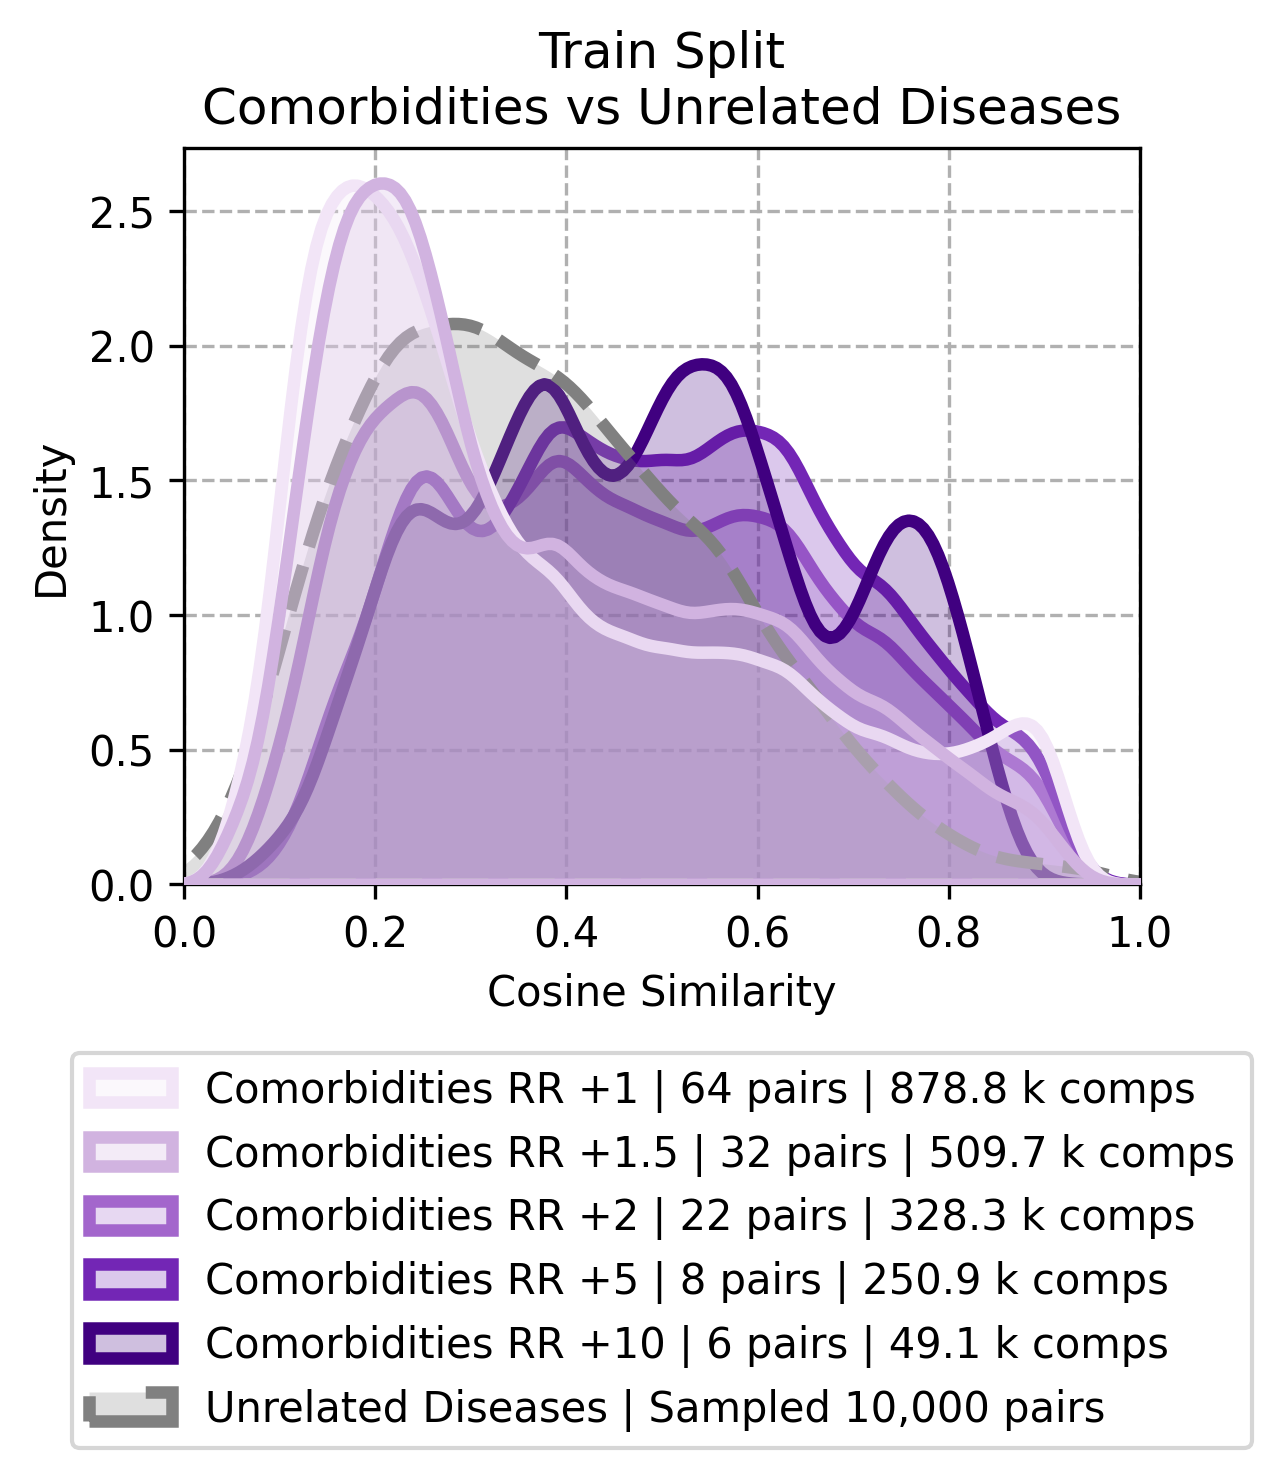

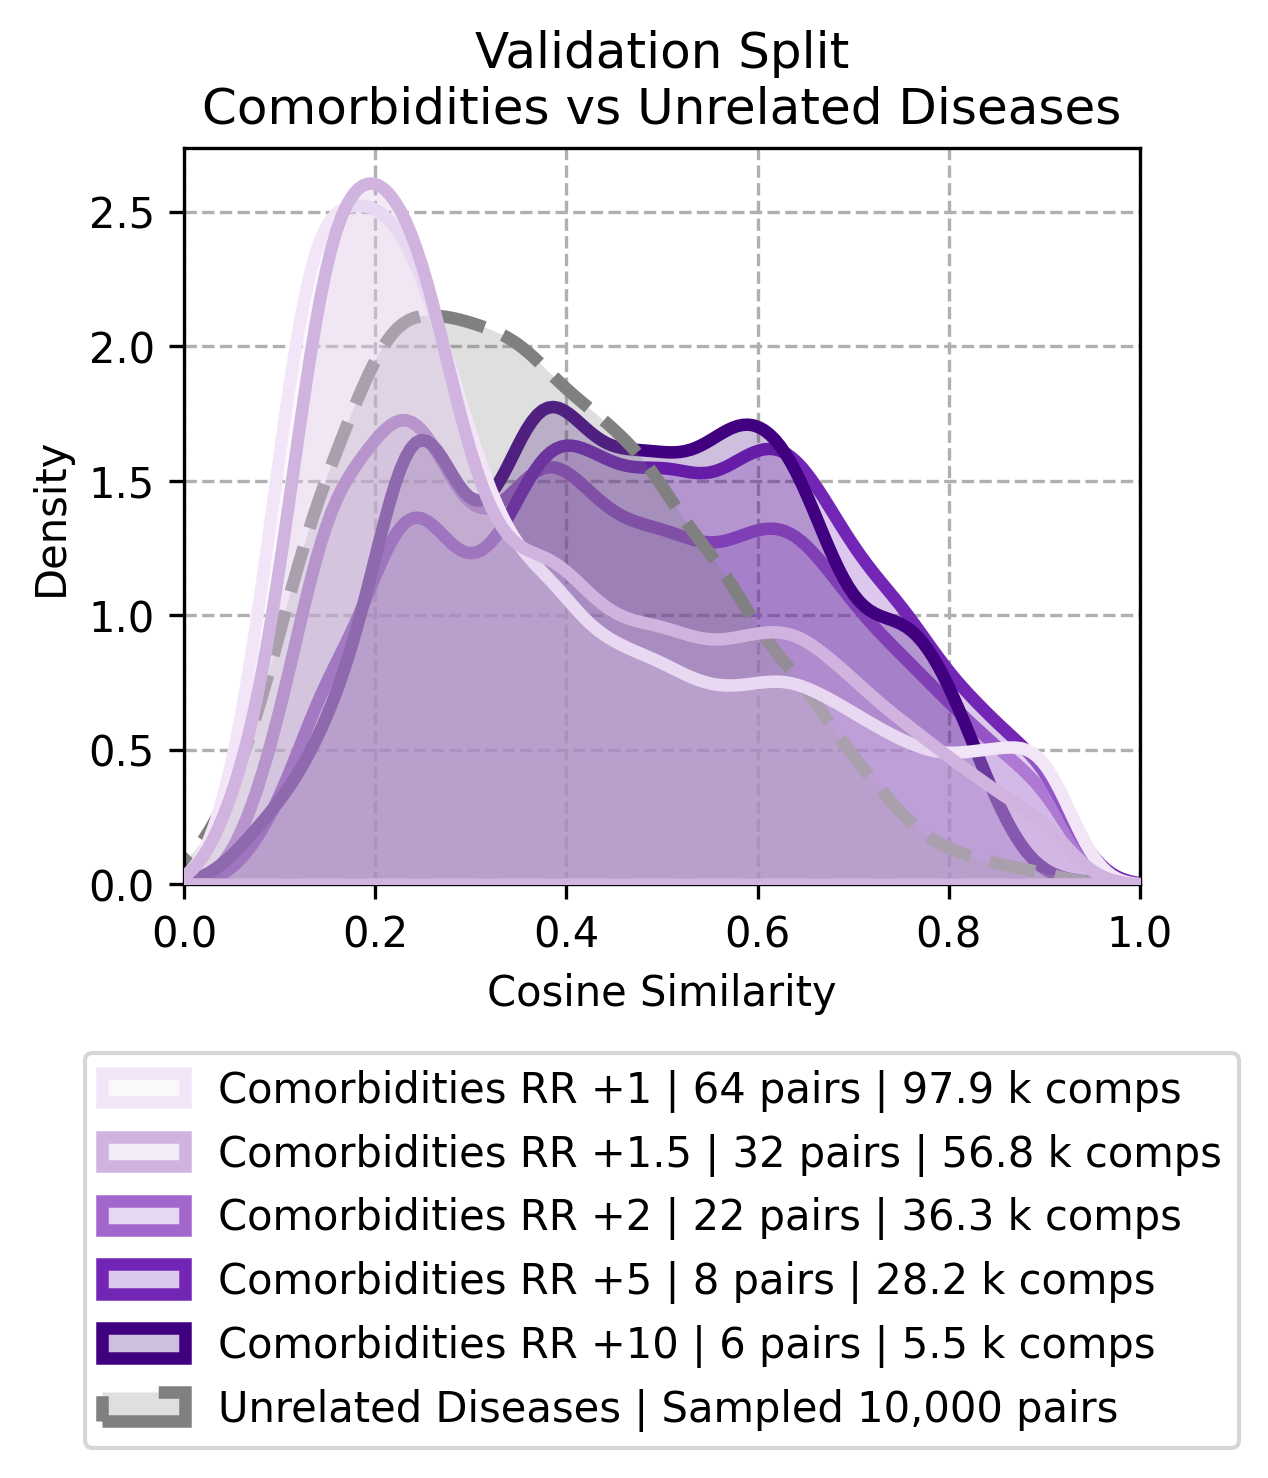

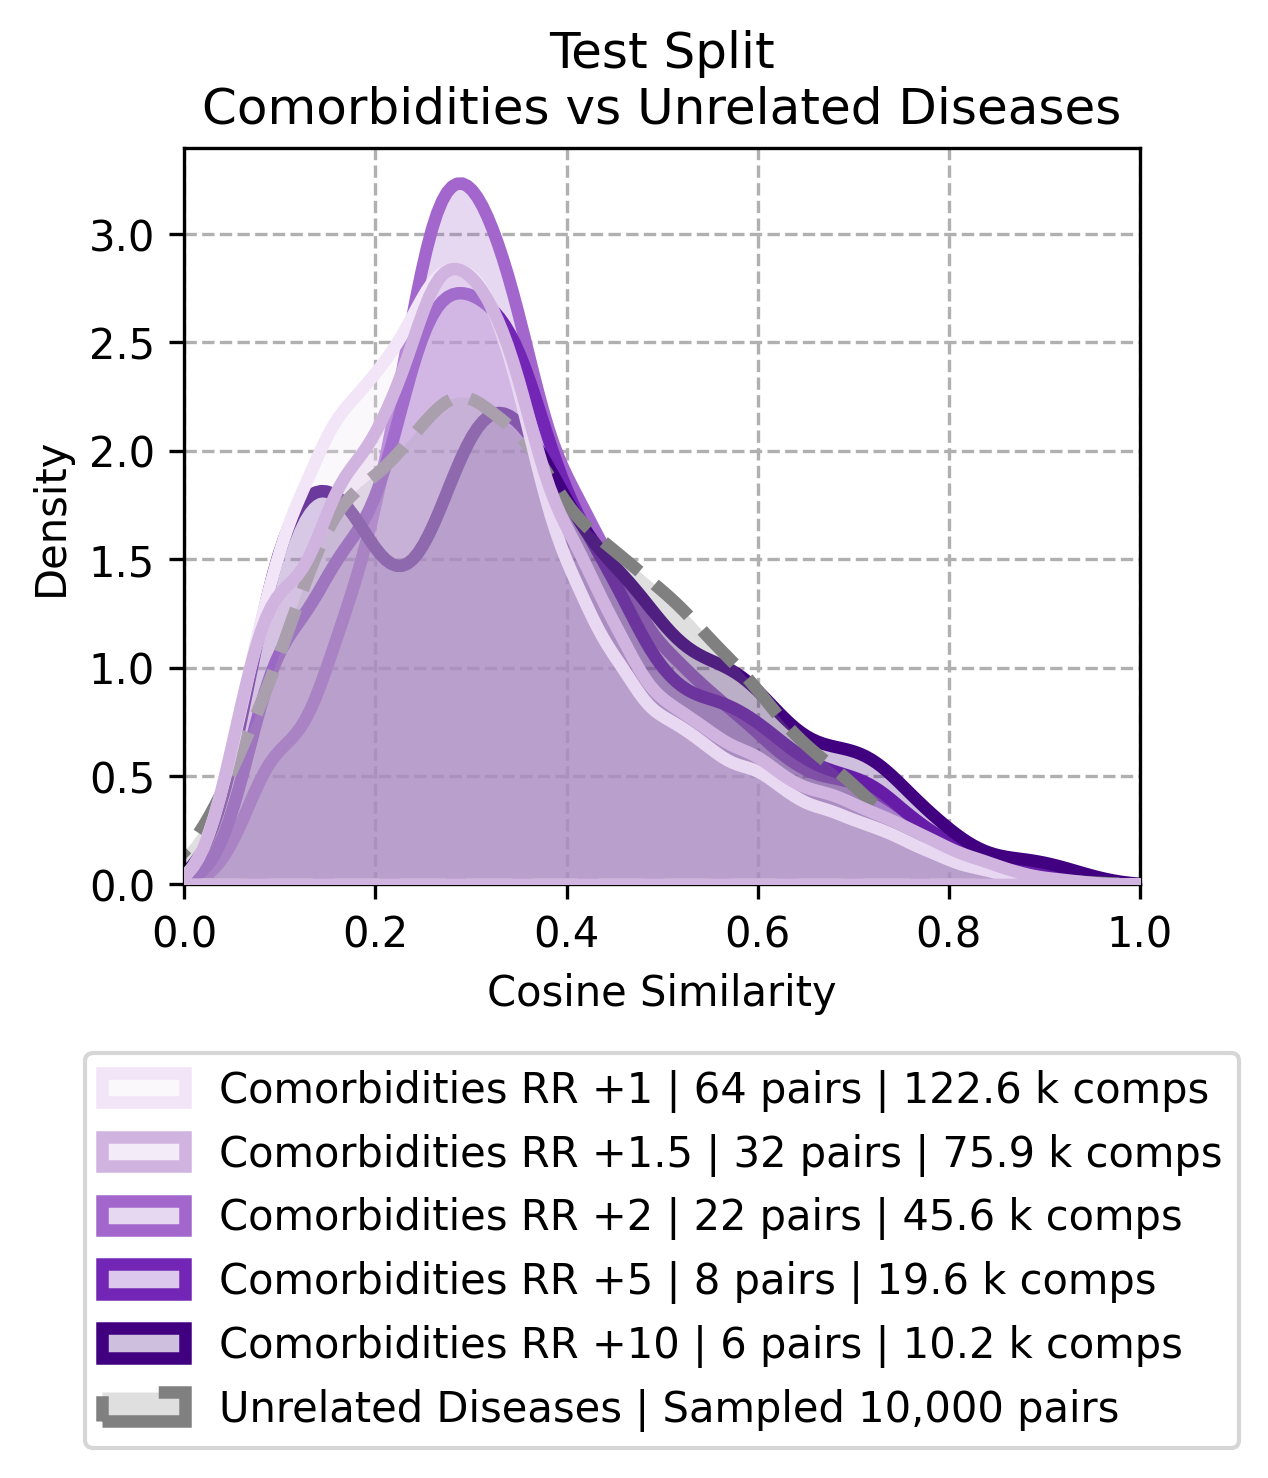

In [34]:
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]

vz.plot_kde(c_com_train + [tr_s_unr], 
            labels=l_com_train + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Train Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,   
            metric="Cosine Similarity")

vz.plot_kde(c_com_valid + [vl_s_unr], 
            labels=l_com_valid + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Validation Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,
            metric="Cosine Similarity")


vz.plot_kde(c_com_test + [ts_s_unr], 
            labels=l_com_test + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Test Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            sample= 1000000,
            weights = None,
            metric="Cosine Similarity")

In [36]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def comb_make_auroc_row(split_name:str, c_com:np.array, s_unr:np.array, ndigits:int=3):
    return pd.DataFrame({
        "Split": [split_name],
        "Comorbidity +1 RR": [round(_auroc(c_com[0], s_unr),ndigits=ndigits)],
        "Comorbidity +1.5 RR": [round(_auroc(c_com[1], s_unr),ndigits=ndigits)],
        "Comorbidity +2 RR": [round(_auroc(c_com[2], s_unr),ndigits=ndigits)],
        "Comorbidity +5 RR": [round(_auroc(c_com[3], s_unr),ndigits=ndigits)],
        "Comorbidity +10 RR": [round(_auroc(c_com[4], s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = comb_make_auroc_row(
    "Train",
    c_com_train,
    tr_s_unr
)

df_auroc_valid = comb_make_auroc_row(
    "Valid",
    c_com_valid,
    vl_s_unr
)

df_auroc_test = comb_make_auroc_row(
    "Test",
    c_com_test,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
# df_auroc.to_csv(os.path.join(output_dir, "gex_auroc_random_all.csv"), index=False)

# df_auroc

Nº of positive disease pairs: 878800
Nº of positive disease pairs: 509726
Nº of positive disease pairs: 328310
Nº of positive disease pairs: 250880
Nº of positive disease pairs: 49108
Nº of positive disease pairs: 97852
Nº of positive disease pairs: 56752
Nº of positive disease pairs: 36288
Nº of positive disease pairs: 28190
Nº of positive disease pairs: 5481
Nº of positive disease pairs: 122607
Nº of positive disease pairs: 75928
Nº of positive disease pairs: 45582
Nº of positive disease pairs: 19623
Nº of positive disease pairs: 10190


In [37]:
df_auroc

,Split,Comorbidity +1 RR,Comorbidity +1.5 RR,Comorbidity +2 RR,Comorbidity +5 RR,Comorbidity +10 RR
0,Train,0.468,0.487,0.591,0.669,0.662
1,Valid,0.466,0.487,0.604,0.675,0.650
2,Test,0.424,0.454,0.516,0.499,0.511
